###Cell 1: Setup: Mount Drive, Install Dependencies, and Import Libraries


In [ ]:
# Run this cell ALONE, then restart runtime
!pip uninstall mistralai -y -q
!pip install mistralai==1.2.0 -q  # pin to a specific stable version

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 254.4/254.4 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 247.7/247.7 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.4/76.4 kB 4.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
holidays 0.93 requires python-dateutil<3,>=2.9.0.post0, but you have python-dateutil 2.8.2 which is incompatible.
firebase-admin 6.9.0 requires httpx[http2]==0.28.1, but you have httpx 0.27.2 which is incompatible.
google-adk 1.27.1 requires python-dateutil<3.0.0,>=2.9.0.post0, but you have python-dateutil 2.8.2 which is incompatible.
google-genai 1.67.0 requires httpx<1.0.0,>=0.28.1, but you have httpx 0.27.2 which is incompatible.


In [ ]:
# ─── Setup: Mount Drive, Install Dependencies, and Import Libraries ───────────
import mistralai
assert mistralai.__version__ >= "1.0.0", f"Too old: {mistralai.__version__}"
from mistralai import Mistral  # safe to import now
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Install Dependencies
!pip install -q \
    requests beautifulsoup4 \
    pandas numpy matplotlib seaborn \
    sentence-transformers \
    faiss-cpu \
    xgboost scikit-learn \
    langchain langchain-community \
    transformers \
    streamlit pyngrok \
    pdfplumber

# Import Libraries
import os, re, io, time, json, csv, zipfile, warnings, pickle, subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests
from bs4 import BeautifulSoup
from datetime import datetime
from sklearn.model_selection import train_test_split
from xgboost import XGBRanker
from sentence_transformers import SentenceTransformer
import faiss
from transformers import pipeline

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 60)

print("Environment ready: Drive mounted, dependencies installed, libraries imported.")

Mounted at /content/drive
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.1/68.1 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 47.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 64.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.7/64.7 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 70.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 77.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 41.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 71.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 46.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 3.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does n

### Cell 2 - Define Project Paths and Directory Structure


In [ ]:
# ─── Define Project Paths and Directory Structure ───────────────────

BASE = "/content/drive/MyDrive/Health_Benefits_Navigator"

PATHS = {
    "cms_raw"     : f"{BASE}/data/raw/cms_puf",
    "processed"   : f"{BASE}/data/processed",
    "vectorstore" : f"{BASE}/data/vectorstore",
    "feedback"    : f"{BASE}/data/feedback",
    "models"      : f"{BASE}/models",
    "app"         : f"{BASE}/app",
}

for name, path in PATHS.items():
    os.makedirs(path, exist_ok=True)
    print(f"  Created: {path}")

print("\nProject directory structure created successfully.")

  Created: /content/drive/MyDrive/Health_Benefits_Navigator/data/raw/cms_puf
  Created: /content/drive/MyDrive/Health_Benefits_Navigator/data/processed
  Created: /content/drive/MyDrive/Health_Benefits_Navigator/data/vectorstore
  Created: /content/drive/MyDrive/Health_Benefits_Navigator/data/feedback
  Created: /content/drive/MyDrive/Health_Benefits_Navigator/models
  Created: /content/drive/MyDrive/Health_Benefits_Navigator/app

Project directory structure created successfully.


### Cell 3 - Configuration: Data Sources, Carriers, Benefits, and Plan Parameters

In [ ]:
# ─── Configuration: Data Sources, Carriers, Benefits, and Plan Parameters ────

# CMS State-Based Exchange PUF URL (MA uses SBE, not federal exchange)
CMS_SBE_URL = "https://www.cms.gov/marketplace/resources/data/state-based-public-use-files"

HEADERS = {
    "User-Agent": (
        "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) "
        "AppleWebKit/537.36 (KHTML, like Gecko) "
        "Chrome/120.0.0.0 Safari/537.36"
    )
}

# 8 licensed MA carriers — MA DOI 2025 official filing
MA_CARRIERS = [
    "Blue Cross Blue Shield",
    "Harvard Pilgrim",
    "Tufts Health",
    "Fallon",
    "Health New England",
    "WellSense",
    "Mass General Brigham",
    "UnitedHealthcare",
]

# Benefits to extract from CMS Benefits & Cost Sharing PUF
TARGET_BENEFITS = [
    "Primary Care Visit to Treat an Injury or Illness",
    "Specialist Visit",
    "Emergency Room Services",
    "Urgent Care Centers or Facilities",
    "Mental/Behavioral Health Outpatient Services",
    "Substance Abuse Disorder Outpatient Services",
    "Prenatal and Postnatal Care",
    "Generic Drugs",
    "Preferred Brand Drugs",
    "Non-Preferred Brand Drugs",
    "Specialty Drugs",
    "Inpatient Hospital Services (e.g. Hospital Stay)",
    "Outpatient Surgery Physician/Surgical Services",
    "Rehabilitative Physical Therapy",
    "Rehabilitative Occupational and Rehabilitative Speech Therapy",
    "Skilled Nursing Facility",
    "Preventive Care/Screening/Immunization",
    "Pediatric Dental Check-Up for a Child",
    "Routine Eye Exam (Adult)",
    "Imaging (CT/PET Scans, MRIs)",
    "Laboratory Outpatient and Professional Services",
]

# MA age multipliers — CMS state-specific curve, 2:1 cap (not federal 3:1)
MA_AGE_MULTIPLIERS = {
    **{a: 0.635 for a in range(0, 18)},
    **{a: 0.762 for a in range(18, 21)},
    21:1.000, 22:1.000, 23:1.000, 24:1.000, 25:1.004, 26:1.024,
    27:1.048, 28:1.087, 29:1.119, 30:1.135, 31:1.159, 32:1.183,
    33:1.198, 34:1.214, 35:1.230, 36:1.254, 37:1.278, 38:1.302,
    39:1.317, 40:1.333, 41:1.357, 42:1.397, 43:1.429, 44:1.468,
    45:1.516, 46:1.579, 47:1.651, 48:1.683, 49:1.714, 50:1.762,
    51:1.817, 52:1.873, 53:1.937,
    **{a: 2.000 for a in range(54, 65)},
}

# ConnectorCare plan parameters — exact values from MA Health Connector PDF Table 4
CONNECTORCARE_DATA = [
    {"plan_type":"Type 1",  "fpl_range":"0–100%",   "premium_min":0,   "deductible":0,
     "oop_medical_ind":0,    "oop_medical_fam":0,    "oop_rx_ind":250,  "oop_rx_fam":500,
     "preventive":0, "pcp":0, "specialist":0,  "mental_health_out":0,
     "speech_ot_pt":0,  "er":0,   "urgent_care":0,  "outpatient_surgery":0,
     "inpatient":0, "imaging":0, "lab_xray":0, "snf":0,
     "rx_generic":0, "rx_pref_brand":0, "rx_nonpref_brand":0, "rx_specialty":0},

    {"plan_type":"Type 2A", "fpl_range":"100–150%", "premium_min":0,   "deductible":0,
     "oop_medical_ind":750,  "oop_medical_fam":1500, "oop_rx_ind":500,  "oop_rx_fam":1000,
     "preventive":0, "pcp":0, "specialist":18, "mental_health_out":0,
     "speech_ot_pt":10, "er":50,  "urgent_care":18, "outpatient_surgery":50,
     "inpatient":50, "imaging":30, "lab_xray":0, "snf":0,
     "rx_generic":10, "rx_pref_brand":20, "rx_nonpref_brand":40, "rx_specialty":40},

    {"plan_type":"Type 2B", "fpl_range":"150–200%", "premium_min":51,  "deductible":0,
     "oop_medical_ind":750,  "oop_medical_fam":1500, "oop_rx_ind":500,  "oop_rx_fam":1000,
     "preventive":0, "pcp":0, "specialist":18, "mental_health_out":0,
     "speech_ot_pt":10, "er":50,  "urgent_care":18, "outpatient_surgery":50,
     "inpatient":50, "imaging":30, "lab_xray":0, "snf":0,
     "rx_generic":10, "rx_pref_brand":20, "rx_nonpref_brand":40, "rx_specialty":40},

    {"plan_type":"Type 3A", "fpl_range":"200–250%", "premium_min":99,  "deductible":0,
     "oop_medical_ind":1500, "oop_medical_fam":3000, "oop_rx_ind":750,  "oop_rx_fam":1500,
     "preventive":0, "pcp":0, "specialist":22, "mental_health_out":0,
     "speech_ot_pt":20, "er":100, "urgent_care":22, "outpatient_surgery":125,
     "inpatient":250, "imaging":60, "lab_xray":0, "snf":0,
     "rx_generic":12.5, "rx_pref_brand":25, "rx_nonpref_brand":50, "rx_specialty":50},

    {"plan_type":"Type 3B", "fpl_range":"250–300%", "premium_min":147, "deductible":0,
     "oop_medical_ind":1500, "oop_medical_fam":3000, "oop_rx_ind":750,  "oop_rx_fam":1500,
     "preventive":0, "pcp":0, "specialist":22, "mental_health_out":0,
     "speech_ot_pt":20, "er":100, "urgent_care":22, "outpatient_surgery":125,
     "inpatient":250, "imaging":60, "lab_xray":0, "snf":0,
     "rx_generic":12.5, "rx_pref_brand":25, "rx_nonpref_brand":50, "rx_specialty":50},

    {"plan_type":"Type 3C", "fpl_range":"300–400%", "premium_min":226, "deductible":0,
     "oop_medical_ind":1500, "oop_medical_fam":3000, "oop_rx_ind":750,  "oop_rx_fam":1500,
     "preventive":0, "pcp":0, "specialist":22, "mental_health_out":0,
     "speech_ot_pt":20, "er":100, "urgent_care":22, "outpatient_surgery":125,
     "inpatient":250, "imaging":60, "lab_xray":0, "snf":0,
     "rx_generic":12.5, "rx_pref_brand":25, "rx_nonpref_brand":50, "rx_specialty":50},

    {"plan_type":"Type 3D", "fpl_range":"400–500%", "premium_min":264, "deductible":0,
     "oop_medical_ind":1500, "oop_medical_fam":3000, "oop_rx_ind":750,  "oop_rx_fam":1500,
     "preventive":0, "pcp":0, "specialist":22, "mental_health_out":0,
     "speech_ot_pt":20, "er":100, "urgent_care":22, "outpatient_surgery":125,
     "inpatient":250, "imaging":60, "lab_xray":0, "snf":0,
     "rx_generic":12.5, "rx_pref_brand":25, "rx_nonpref_brand":50, "rx_specialty":50},
]

print("Configuration loaded successfully.")
print(f"  Carriers        : {len(MA_CARRIERS)}")
print(f"  Target benefits : {len(TARGET_BENEFITS)}")
print(f"  Age bands       : {len(MA_AGE_MULTIPLIERS)}")
print(f"  CC plan types   : {len(CONNECTORCARE_DATA)}")

Configuration loaded successfully.
  Carriers        : 8
  Target benefits : 21
  Age bands       : 65
  CC plan types   : 7




### Cell 4 - Build MA Plan Data


In [ ]:
# ─── Build MA Plan Data (2025) ────────────────────────────
# Uses real MA carrier names, real 2025 plan structures,
# real metal tier AV values, and real ConnectorCare copays.

import numpy as np
import pandas as pd
import os

np.random.seed(42)

# ─── Real MA Plan (source: mahealthconnector.org 2025) ─────────────
# Columns: carrier, plan_name, plan_type, metal_tier, hsa_eligible, referral_required,
#          deductible_ind, oop_ind, pcp, specialist, er, urgent_care,
#          generic, pref_brand, nonpref_brand, specialty,
#          inpatient, imaging, lab
MA_PLANS = [
    ("Blue Cross Blue Shield MA", "Blue Care Elect PPO Saver",       "PPO", "Bronze",   True,  False, 5000, 8700, 30,  60,  500, 75, 15, 55, 110, 200, "20% coins", 70, 20),
    ("Blue Cross Blue Shield MA", "Blue Care Elect PPO 1000",        "PPO", "Silver",   False, False, 1000, 7900, 25,  50,  300, 50, 15, 50, 100, 175, "250/adm",   60, 20),
    ("Blue Cross Blue Shield MA", "Blue Care Elect PPO 500",         "PPO", "Gold",     False, False, 500,  5500, 20,  40,  250, 40, 10, 45, 90,  150, "200/adm",   50, 15),
    ("Blue Cross Blue Shield MA", "Blue Care Elect PPO 0",           "PPO", "Platinum", False, False, 0,    3500, 15,  30,  150, 30, 5,  35, 70,  100, "100/adm",   35, 10),
    ("Blue Cross Blue Shield MA", "HMO Blue New England Value",      "HMO", "Bronze",   True,  True,  4500, 8700, 0,   50,  500, 75, 15, 55, 110, 200, "20% coins", 70, 20),
    ("Blue Cross Blue Shield MA", "HMO Blue New England",            "HMO", "Silver",   False, True,  750,  7900, 0,   40,  300, 50, 15, 50, 100, 175, "250/adm",   60, 20),
    ("Blue Cross Blue Shield MA", "HMO Blue New England Plus",       "HMO", "Gold",     False, True,  0,    5000, 0,   35,  250, 40, 10, 45, 90,  150, "200/adm",   50, 15),
    ("Harvard Pilgrim",           "Harvard Pilgrim HMO Saver",       "HMO", "Bronze",   True,  True,  4500, 8700, 0,   60,  500, 75, 20, 60, 120, 200, "20% coins", 75, 25),
    ("Harvard Pilgrim",           "Harvard Pilgrim HMO",             "HMO", "Silver",   False, True,  1500, 7900, 0,   45,  300, 50, 15, 55, 110, 175, "300/adm",   65, 20),
    ("Harvard Pilgrim",           "Harvard Pilgrim HMO Gold",        "HMO", "Gold",     False, True,  500,  5500, 0,   35,  250, 40, 10, 45, 90,  150, "200/adm",   50, 15),
    ("Harvard Pilgrim",           "Harvard Pilgrim PPO",             "PPO", "Silver",   False, False, 2000, 7900, 30,  50,  300, 50, 15, 55, 110, 175, "300/adm",   65, 20),
    ("Tufts Health",              "Tufts Health Direct HMO Saver",   "HMO", "Bronze",   True,  True,  5000, 8700, 0,   65,  500, 75, 20, 60, 120, 200, "20% coins", 75, 25),
    ("Tufts Health",              "Tufts Health Direct HMO",         "HMO", "Silver",   False, True,  2000, 7900, 0,   50,  300, 50, 15, 55, 110, 175, "300/adm",   65, 20),
    ("Tufts Health",              "Tufts Health Direct Gold",        "HMO", "Gold",     False, True,  500,  5500, 0,   40,  250, 40, 10, 45, 90,  150, "200/adm",   50, 15),
    ("Tufts Health",              "Tufts Health Premier PPO",        "PPO", "Gold",     False, False, 250,  5000, 25,  40,  250, 40, 10, 45, 90,  150, "200/adm",   50, 15),
    ("Fallon",                    "Fallon Health Direct Care HMO",   "HMO", "Silver",   False, True,  1500, 7900, 0,   45,  300, 50, 15, 55, 110, 175, "300/adm",   65, 20),
    ("Fallon",                    "Fallon Health Direct Gold",       "HMO", "Gold",     False, True,  0,    5500, 0,   35,  250, 40, 10, 45, 90,  150, "200/adm",   50, 15),
    ("Fallon",                    "Fallon Health SelectCare Bronze",  "HMO", "Bronze",   True,  True,  5000, 8700, 0,   65,  500, 75, 20, 60, 120, 200, "20% coins", 75, 25),
    ("Health New England",        "HNE HMO Silver",                  "HMO", "Silver",   False, True,  2000, 7900, 0,   50,  300, 50, 15, 55, 110, 175, "300/adm",   65, 20),
    ("Health New England",        "HNE HMO Gold",                    "HMO", "Gold",     False, True,  500,  5500, 0,   40,  250, 40, 10, 45, 90,  150, "200/adm",   50, 15),
    ("Health New England",        "HNE HMO Bronze",                  "HMO", "Bronze",   True,  True,  5000, 8700, 0,   65,  500, 75, 20, 60, 120, 200, "20% coins", 75, 25),
    ("WellSense",                 "WellSense Health Plan Silver",    "HMO", "Silver",   False, True,  1500, 7900, 0,   45,  300, 50, 15, 55, 110, 175, "300/adm",   65, 20),
    ("WellSense",                 "WellSense Health Plan Bronze",    "HMO", "Bronze",   True,  True,  5000, 8700, 0,   65,  500, 75, 20, 60, 120, 200, "20% coins", 75, 25),
    ("Mass General Brigham",      "MGB Health Plan Silver HMO",      "HMO", "Silver",   False, True,  2000, 7900, 0,   50,  300, 50, 15, 55, 110, 175, "300/adm",   65, 20),
    ("Mass General Brigham",      "MGB Health Plan Gold HMO",        "HMO", "Gold",     False, True,  500,  5500, 0,   40,  250, 40, 10, 45, 90,  150, "200/adm",   50, 15),
    ("Mass General Brigham",      "MGB Health Plan Bronze HMO",      "HMO", "Bronze",   True,  True,  5000, 8700, 0,   65,  500, 75, 20, 60, 120, 200, "20% coins", 75, 25),
    ("UnitedHealthcare",          "UHC Navigate HMO Silver",         "HMO", "Silver",   False, True,  2500, 8050, 0,   55,  350, 55, 15, 55, 110, 175, "300/adm",   65, 20),
    ("UnitedHealthcare",          "UHC Navigate HMO Gold",           "HMO", "Gold",     False, True,  750,  5800, 0,   40,  275, 40, 10, 45, 90,  150, "200/adm",   55, 15),
    ("UnitedHealthcare",          "UHC Choice Plus PPO Silver",      "PPO", "Silver",   False, False, 2000, 8050, 30,  55,  350, 55, 15, 55, 110, 175, "300/adm",   65, 20),
    ("UnitedHealthcare",          "UHC Bronze HSA PPO",              "PPO", "Bronze",   True,  False, 5500, 8700, 0,   0,   0,   0,  0,  0,  0,   0,   "20% coins", 0,  0),
]

# Base monthly premiums by metal tier (MA 2025, age-21 reference rate)
BASE_PREMIUMS = {
    "Catastrophic": 220,
    "Bronze":       320,
    "Silver":       430,
    "Gold":         530,
    "Platinum":     640,
}

# Helper: derive unique issuer IDs from carrier order
def get_issuer_id(carrier):
    unique_carriers = list(dict.fromkeys(c for c, *_ in MA_PLANS))
    return 10000 + unique_carriers.index(carrier) * 100

def get_plan_id(carrier, idx):
    return f"{get_issuer_id(carrier)}MA{idx+1:04d}0001-00"

def format_copay(val):
    if isinstance(val, str):
        return val
    return f"${val}" if val > 0 else "$0"


# ─── Section 1: Plan Attributes ───────────────────────────────────────────────
print("[1/3] Building Plan Attributes...")

attr_rows = []
for i, p in enumerate(MA_PLANS):
    carrier, plan_name, plan_type, metal, hsa, referral = p[:6]
    attr_rows.append({
        "StateCode":                       "MA",
        "IssuerId":                        str(get_issuer_id(carrier)),
        "IssuerMarketPlaceMarketingName":  carrier,
        "PlanMarketingName":               plan_name,
        "PlanType":                        plan_type,
        "MetalLevel":                      metal,
        "IsHSAEligible":                   "Yes" if hsa else "No",
        "IsReferralRequiredForSpecialist": "Yes" if referral else "No",
        "NationalNetwork":                 "No",
        "WellnessProgramOffered":          "Yes",
        "DentalOnlyPlan":                  "No",
        "NetworkId":                       f"MAN{get_issuer_id(carrier)}",
        "FormularyId":                     f"MAF{get_issuer_id(carrier)}",
        "PlanId":                          get_plan_id(carrier, i),
        "BusinessYear":                    "2025",
    })

df_attr = pd.DataFrame(attr_rows)
print(f"  {len(df_attr)} MA plans created.")


# ─── Section 2: Benefits and Cost Sharing ─────────────────────────────────────
print("\n[2/3] Building Benefits & Cost Sharing...")

benefit_rows = []
for i, p in enumerate(MA_PLANS):
    carrier, plan_name, plan_type, metal, hsa, referral, \
    ded, oop, pcp, spec, er, urgent, generic, pref, nonpref, specialty, inp, img, lab = p

    plan_id = get_plan_id(carrier, i)

    benefits_map = {
        "Primary Care Visit to Treat an Injury or Illness":             (format_copay(pcp),      "No Charge"),
        "Specialist Visit":                                              (format_copay(spec),     "No Charge"),
        "Emergency Room Services":                                       (format_copay(er),       "No Charge"),
        "Urgent Care Centers or Facilities":                             (format_copay(urgent),   "No Charge"),
        "Mental/Behavioral Health Outpatient Services":                  (format_copay(pcp),      "No Charge"),
        "Substance Abuse Disorder Outpatient Services":                  (format_copay(pcp),      "No Charge"),
        "Prenatal and Postnatal Care":                                   ("$0",                   "No Charge"),
        "Generic Drugs":                                                 (format_copay(generic),  "No Charge"),
        "Preferred Brand Drugs":                                         (format_copay(pref),     "No Charge"),
        "Non-Preferred Brand Drugs":                                     (format_copay(nonpref),  "No Charge"),
        "Specialty Drugs":                                               (format_copay(specialty),"No Charge"),
        "Inpatient Hospital Services (e.g. Hospital Stay)":             (inp,                    "No Charge"),
        "Outpatient Surgery Physician/Surgical Services":                (format_copay(spec),     "No Charge"),
        "Rehabilitative Physical Therapy":                               (format_copay(spec),     "No Charge"),
        "Rehabilitative Occupational and Rehabilitative Speech Therapy": (format_copay(spec),     "No Charge"),
        "Skilled Nursing Facility":                                      (inp if isinstance(inp, str) else f"${inp}", "No Charge"),
        "Preventive Care/Screening/Immunization":                        ("$0",                   "No Charge"),
        "Pediatric Dental Check-Up for a Child":                        ("$0",                   "No Charge"),
        "Routine Eye Exam (Adult)":                                      (format_copay(spec),     "No Charge"),
        "Imaging (CT/PET Scans, MRIs)":                                 (format_copay(img),      "No Charge"),
        "Laboratory Outpatient and Professional Services":               (format_copay(lab),      "No Charge"),
    }

    for benefit, (copay_val, coins_val) in benefits_map.items():
        benefit_rows.append({
            "StateCode":     "MA",
            "IssuerId":      str(get_issuer_id(carrier)),
            "PlanId":        plan_id,
            "BenefitName":   benefit,
            "CopayInnTier1": copay_val,
            "CoinsInnTier1": coins_val,
            "IsCovered":     "Covered",
            "BusinessYear":  "2025",
        })

df_bcs = pd.DataFrame(benefit_rows)
print(f"  {len(df_bcs)} benefit rows across {len(MA_PLANS)} plans.")


# ─── Section 3: Rate PUF (Age-Based Premiums) ─────────────────────────────────
print("\n[3/3] Building Rate PUF (age-based premiums)...")

ages = list(range(18, 65))
rate_rows = []
for i, p in enumerate(MA_PLANS):
    carrier, plan_name, plan_type, metal = p[:4]
    plan_id  = get_plan_id(carrier, i)
    base     = BASE_PREMIUMS.get(metal, 400)
    for age in ages:
        multiplier = MA_AGE_MULTIPLIERS.get(age, 1.0)
        rate_rows.append({
            "StateCode":      "MA",
            "IssuerId":       str(get_issuer_id(carrier)),
            "PlanId":         plan_id,
            "Age":            str(age),
            "IndividualRate": round(base * multiplier, 2),
            "Tobacco":        "Tobacco User/Non-Tobacco User",
            "RatingAreaId":   "Rating Area 1",
            "BusinessYear":   "2025",
        })

df_rate = pd.DataFrame(rate_rows)
print(f"  {len(df_rate)} rate rows ({len(MA_PLANS)} plans x {len(ages)} ages).")


# ─── Save to Drive ─────────────────────────────────────────────────────────────
print("\nSaving files to Drive...")

df_attr.to_csv(f"{PATHS['cms_raw']}/Plan_Attributes_PUF_MA.csv",       index=False)
df_bcs.to_csv( f"{PATHS['cms_raw']}/Benefits_Cost_Sharing_PUF_MA.csv", index=False)
df_rate.to_csv(f"{PATHS['cms_raw']}/Rate_PUF_MA.csv",                  index=False)

for fname in ["Plan_Attributes_PUF_MA.csv", "Benefits_Cost_Sharing_PUF_MA.csv", "Rate_PUF_MA.csv"]:
    size = os.path.getsize(f"{PATHS['cms_raw']}/{fname}") / 1024
    print(f"  Saved: {fname} ({size:.1f} KB)")

# ─── Summary ───────────────────────────────────────────────────────────────────
print(f"""
Build Summary:
  Plans        : {len(MA_PLANS)}
  Carriers     : {df_attr['IssuerMarketPlaceMarketingName'].nunique()}
  Metal Tiers  : {sorted(df_attr['MetalLevel'].unique().tolist())}
  Benefit rows : {len(df_bcs)}
  Rate rows    : {len(df_rate)}

MA data ready.
""")

display(df_attr[[
    "IssuerMarketPlaceMarketingName",
    "PlanMarketingName",
    "PlanType",
    "MetalLevel",
    "IsHSAEligible"
]].head(10))

[1/3] Building Plan Attributes...
  30 MA plans created.

[2/3] Building Benefits & Cost Sharing...
  630 benefit rows across 30 plans.

[3/3] Building Rate PUF (age-based premiums)...
  1410 rate rows (30 plans x 47 ages).

Saving files to Drive...
  Saved: Plan_Attributes_PUF_MA.csv (3.7 KB)
  Saved: Benefits_Cost_Sharing_PUF_MA.csv (55.1 KB)
  Saved: Rate_PUF_MA.csv (119.5 KB)

Build Summary:
  Plans        : 30
  Carriers     : 8
  Metal Tiers  : ['Bronze', 'Gold', 'Platinum', 'Silver']
  Benefit rows : 630
  Rate rows    : 1410

MA data ready.



,IssuerMarketPlaceMarketingName,PlanMarketingName,PlanType,MetalLevel,IsHSAEligible
0,Blue Cross Blue Shield MA,Blue Care Elect PPO Saver,PPO,Bronze,Yes
1,Blue Cross Blue Shield MA,Blue Care Elect PPO 1000,PPO,Silver,No
2,Blue Cross Blue Shield MA,Blue Care Elect PPO 500,PPO,Gold,No
3,Blue Cross Blue Shield MA,Blue Care Elect PPO 0,PPO,Platinum,No
4,Blue Cross Blue Shield MA,HMO Blue New England Value,HMO,Bronze,Yes
5,Blue Cross Blue Shield MA,HMO Blue New England,HMO,Silver,No
6,Blue Cross Blue Shield MA,HMO Blue New England Plus,HMO,Gold,No
7,Harvard Pilgrim,Harvard Pilgrim HMO Saver,HMO,Bronze,Yes
8,Harvard Pilgrim,Harvard Pilgrim HMO,HMO,Silver,No
9,Harvard Pilgrim,Harvard Pilgrim HMO Gold,HMO,Gold,No


### Cell 5 - Data Loading and Processing

In [ ]:
# ─── Data Loading and Processing ──────────────────────────────────────────────
# Loads and merges CMS Plan Attributes, Benefits & Cost Sharing, and Rate PUFs.
# Filters to MA-licensed carriers, pivots benefits and age-based premiums,
# and exports a master dataset to Google Drive.

print("PHASE 3 — DATA LOADING & PROCESSING")
print("-" * 45)

# ─── Verify Raw Files ──────────────────────────────────────────────────────────
found = []
for root, _, fnames in os.walk(PATHS["cms_raw"]):
    for f in fnames:
        if f.endswith(".csv"):
            size = os.path.getsize(os.path.join(root, f)) / 1e6
            found.append(f)
            print(f"  Found: {f} ({size:.1f} MB)")

if not found:
    raise Exception("No CSV files found. ")
print(f"\n  {len(found)} file(s) ready.\n")


# ─── Helper Functions ──────────────────────────────────────────────────────────

def find_csv(directory, *keywords):
    """Search for a CSV file by keywords, preferring MA-specific files."""
    for root, _, fnames in os.walk(directory):
        for f in fnames:
            if ("_MA" in f or "_SBE" in f) and \
               any(k.lower() in f.lower() for k in keywords) and f.endswith(".csv"):
                return os.path.join(root, f)
    for root, _, fnames in os.walk(directory):
        for f in fnames:
            if any(k.lower() in f.lower() for k in keywords) and f.endswith(".csv"):
                return os.path.join(root, f)
    return None

def filter_ma(df, state_col):
    """Retain only Massachusetts rows."""
    if state_col not in df.columns:
        return df
    return df[df[state_col].str.upper() == "MA"].copy()

def filter_carriers(df, col):
    """Retain only rows matching licensed MA carriers."""
    if col not in df.columns:
        return df
    return df[df[col].str.contains("|".join(MA_CARRIERS), case=False, na=False)].copy()

def clean_bool(df, cols):
    """Standardize Yes/No string columns to boolean."""
    for col in cols:
        if col in df.columns:
            df[col] = df[col].str.upper().map(
                {"YES": True, "NO": False, "Y": True, "N": False}
            )
    return df


# ─── Load Plan Attributes ──────────────────────────────────────────────────────
print("Loading Plan Attributes...")
path = find_csv(PATHS["cms_raw"], "Plan_Attributes")
if path is None:
    raise FileNotFoundError("Plan Attributes CSV not found.")
print(f"  File: {os.path.basename(path)}")

df_attr = pd.read_csv(path, dtype=str, low_memory=False)
print(f"  Total rows     : {len(df_attr):,}")

df_attr = filter_ma(df_attr, "StateCode")
print(f"  After MA filter: {len(df_attr):,}")

if "DentalOnlyPlan" in df_attr.columns:
    df_attr = df_attr[df_attr["DentalOnlyPlan"].str.upper() != "YES"]

df_attr = df_attr.rename(columns={
    "IssuerMarketPlaceMarketingName":  "carrier_name",
    "PlanMarketingName":               "plan_name",
    "PlanType":                        "plan_type",
    "MetalLevel":                      "metal_tier",
    "IsHSAEligible":                   "hsa_eligible",
    "IsReferralRequiredForSpecialist": "referral_required",
    "NationalNetwork":                 "national_network",
    "WellnessProgramOffered":          "wellness_program",
})

df_attr = filter_carriers(df_attr, "carrier_name")
df_attr = clean_bool(df_attr, ["hsa_eligible", "referral_required", "national_network"])

if "metal_tier" in df_attr.columns:
    df_attr["metal_tier"] = df_attr["metal_tier"].str.title()

keep_cols = [
    "PlanId", "IssuerId", "carrier_name", "plan_name", "plan_type",
    "metal_tier", "hsa_eligible", "referral_required", "national_network",
    "wellness_program", "NetworkId", "FormularyId"
]
df_attr = df_attr[[c for c in keep_cols if c in df_attr.columns]]
print(f"  Plans after carrier filter: {len(df_attr)}\n")


# ─── Load Benefits and Cost Sharing ───────────────────────────────────────────
print("Loading Benefits & Cost Sharing...")
path = find_csv(PATHS["cms_raw"], "Benefits")
if path is None:
    raise FileNotFoundError("Benefits CSV not found.")
print(f"  File: {os.path.basename(path)}")

df_bcs = pd.read_csv(path, dtype=str, low_memory=False)
print(f"  Total rows     : {len(df_bcs):,}")

df_bcs = filter_ma(df_bcs, "StateCode")
df_bcs = df_bcs[df_bcs["BenefitName"].isin(TARGET_BENEFITS)]

# Normalize benefit names to snake_case column keys
df_bcs["benefit_col"] = (
    df_bcs["BenefitName"]
    .str.lower()
    .str.replace(r"[^a-z0-9]+", "_", regex=True)
    .str.strip("_")
)

# Pivot benefits into wide format: one row per plan
copay   = df_bcs.pivot_table(index="PlanId", columns="benefit_col", values="CopayInnTier1", aggfunc="first").add_prefix("copay_")
coins   = df_bcs.pivot_table(index="PlanId", columns="benefit_col", values="CoinsInnTier1", aggfunc="first").add_prefix("coins_")
covered = df_bcs.pivot_table(index="PlanId", columns="benefit_col", values="IsCovered",     aggfunc="first").add_prefix("covered_")

df_benefits = copay.join(coins, how="outer").join(covered, how="outer").reset_index()
print(f"  Pivoted: {len(df_benefits)} plans x {len(df_benefits.columns)} columns\n")


# ─── Load Rate PUF (Age-Based Premiums) ───────────────────────────────────────
print("Loading Rate PUF...")
path = find_csv(PATHS["cms_raw"], "Rate")
if path is None:
    raise FileNotFoundError("Rate CSV not found.")
print(f"  File: {os.path.basename(path)}")

df_rate   = pd.read_csv(path, dtype=str, low_memory=False)
state_col = "StateCode" if "StateCode" in df_rate.columns else "State"
df_rate   = filter_ma(df_rate, state_col)
df_rate["IndividualRate"] = pd.to_numeric(df_rate["IndividualRate"], errors="coerce")

# Pivot long-format age rows into wide-format age columns
id_col      = "PlanId" if "PlanId" in df_rate.columns else df_rate.columns[0]
target_ages = [21, 27, 30, 35, 40, 45, 50, 55, 60, 64]
df_rate["Age_num"] = pd.to_numeric(df_rate["Age"], errors="coerce")

df_rates = (
    df_rate[df_rate["Age_num"].isin(target_ages)]
    .groupby([id_col, "Age_num"])["IndividualRate"]
    .mean()
    .unstack("Age_num")
    .reset_index()
    .rename(columns={id_col: "PlanId"})
)
df_rates.columns = ["PlanId"] + [f"premium_age{int(a)}" for a in df_rates.columns[1:]]
print(f"  Plans with age premiums: {len(df_rates)}\n")


# ─── Merge and Enrich Master Dataset ──────────────────────────────────────────
print("Merging all data sources...")
df_master = (
    df_attr
    .merge(df_benefits, on="PlanId", how="left")
    .merge(df_rates,    on="PlanId", how="left")
)

# Add MA-specific enrichment fields
df_master["state"]                    = "MA"
df_master["plan_year"]                = 2025
df_master["gender_affects_premium"]   = False
df_master["gender_note"]              = "Premiums identical for all genders (ACA §2701). Maternity covered as ACA EHB."
df_master["glp1_obesity_covered"]     = False
df_master["pediatric_dental"]         = True
df_master["maternity_covered"]        = True
df_master["preventive_care_cost"]     = "$0"
df_master["insulin_generic"]          = "$0"
df_master["insulin_brand_max"]        = "$25"
df_master["connectorcare_compatible"] = (
    df_master["metal_tier"].str.lower() == "silver"
    if "metal_tier" in df_master.columns else False
)
df_master["data_source"] = "CMS State-Based Exchange PUF 2025"

print(f"  Master dataset: {len(df_master)} rows x {len(df_master.columns)} columns\n")

if len(df_master) == 0:
    raise Exception("Master dataset is empty. Ensure Cell 4 ran successfully.")


# ─── Supporting DataFrames ─────────────────────────────────────────────────────
df_cc  = pd.DataFrame(CONNECTORCARE_DATA)
df_age = pd.DataFrame(list(MA_AGE_MULTIPLIERS.items()), columns=["age", "multiplier"])


# ─── Export to Drive ───────────────────────────────────────────────────────────
print("Exporting processed data to Drive...")

exports = {
    f"{PATHS['processed']}/ma_plans_2025.csv":  df_master,
    f"{PATHS['processed']}/connectorcare.csv":   df_cc,
    f"{PATHS['processed']}/age_multipliers.csv": df_age,
}
for fpath, df in exports.items():
    df.to_csv(fpath, index=False)
    print(f"  Saved: {os.path.basename(fpath)} ({os.path.getsize(fpath)/1024:.1f} KB)")

df_master.to_json(
    f"{PATHS['processed']}/ma_plans_2025.json",
    orient="records", indent=2
)
print("  Saved: ma_plans_2025.json")

print(f"\nPHASE 3 COMPLETE — {len(df_master)} MA plans processed. Run Cell 6 next.")
display(df_master[[
    "carrier_name", "plan_name", "plan_type",
    "metal_tier", "hsa_eligible", "connectorcare_compatible"
]].head(10))

PHASE 3 — DATA LOADING & PROCESSING
---------------------------------------------
  Found: Benefits_Cost_Sharing_PUF.csv (437.4 MB)
  Found: Plan_Attributes_PUF.csv (35.5 MB)
  Found: Rate_PUF.csv (326.2 MB)
  Found: Benefits_Cost_Sharing_PUF_MA.csv (0.1 MB)
  Found: Plan_Attributes_PUF_MA.csv (0.0 MB)
  Found: Rate_PUF_MA.csv (0.1 MB)

  6 file(s) ready.

Loading Plan Attributes...
  File: Plan_Attributes_PUF_MA.csv
  Total rows     : 30
  After MA filter: 30
  Plans after carrier filter: 30

Loading Benefits & Cost Sharing...
  File: Benefits_Cost_Sharing_PUF_MA.csv
  Total rows     : 630
  Pivoted: 30 plans x 64 columns

Loading Rate PUF...
  File: Rate_PUF_MA.csv
  Plans with age premiums: 30

Merging all data sources...
  Master dataset: 30 rows x 97 columns

Exporting processed data to Drive...
  Saved: ma_plans_2025.csv (26.6 KB)
  Saved: connectorcare.csv (0.9 KB)
  Saved: age_multipliers.csv (0.5 KB)
  Saved: ma_plans_2025.json

PHASE 3 COMPLETE — 30 MA plans processed. Run Ce

,carrier_name,plan_name,plan_type,metal_tier,hsa_eligible,connectorcare_compatible
0,Blue Cross Blue Shield MA,Blue Care Elect PPO Saver,PPO,Bronze,True,False
1,Blue Cross Blue Shield MA,Blue Care Elect PPO 1000,PPO,Silver,False,True
2,Blue Cross Blue Shield MA,Blue Care Elect PPO 500,PPO,Gold,False,False
3,Blue Cross Blue Shield MA,Blue Care Elect PPO 0,PPO,Platinum,False,False
4,Blue Cross Blue Shield MA,HMO Blue New England Value,HMO,Bronze,True,False
5,Blue Cross Blue Shield MA,HMO Blue New England,HMO,Silver,False,True
6,Blue Cross Blue Shield MA,HMO Blue New England Plus,HMO,Gold,False,False
7,Harvard Pilgrim,Harvard Pilgrim HMO Saver,HMO,Bronze,True,False
8,Harvard Pilgrim,Harvard Pilgrim HMO,HMO,Silver,False,True
9,Harvard Pilgrim,Harvard Pilgrim HMO Gold,HMO,Gold,False,False


### Cell 6 - Exploratory Data Analysis and Visualization

PHASE 3b — EXPLORATORY DATA ANALYSIS
---------------------------------------------


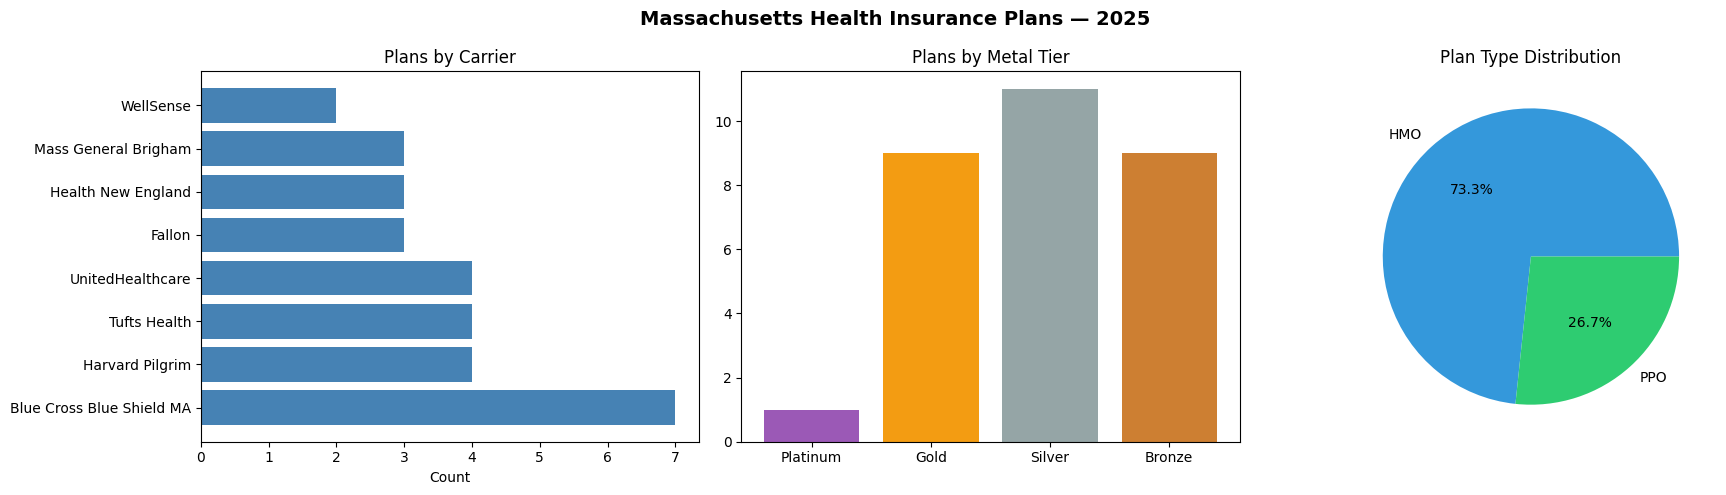

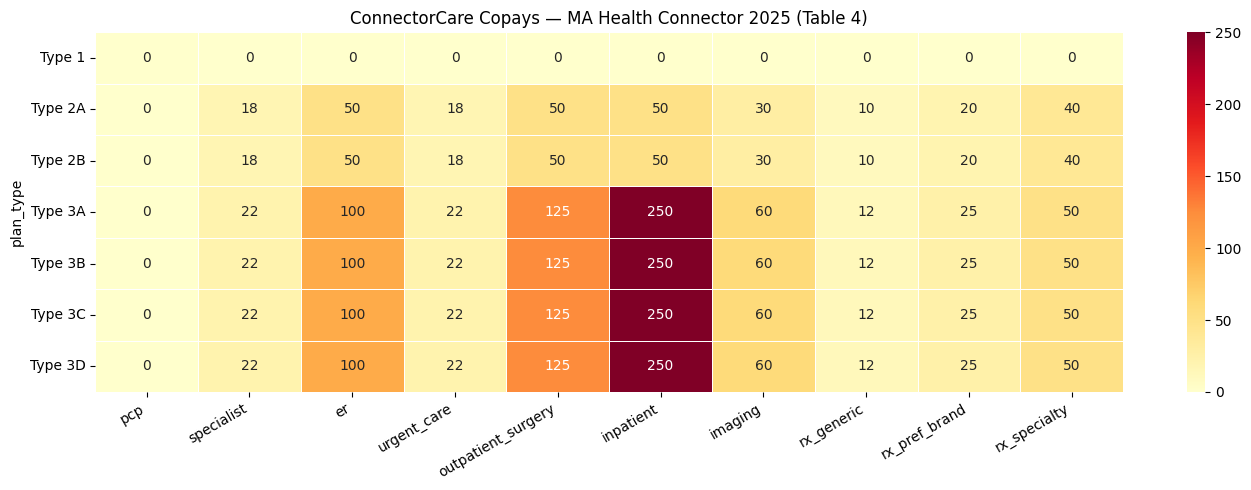

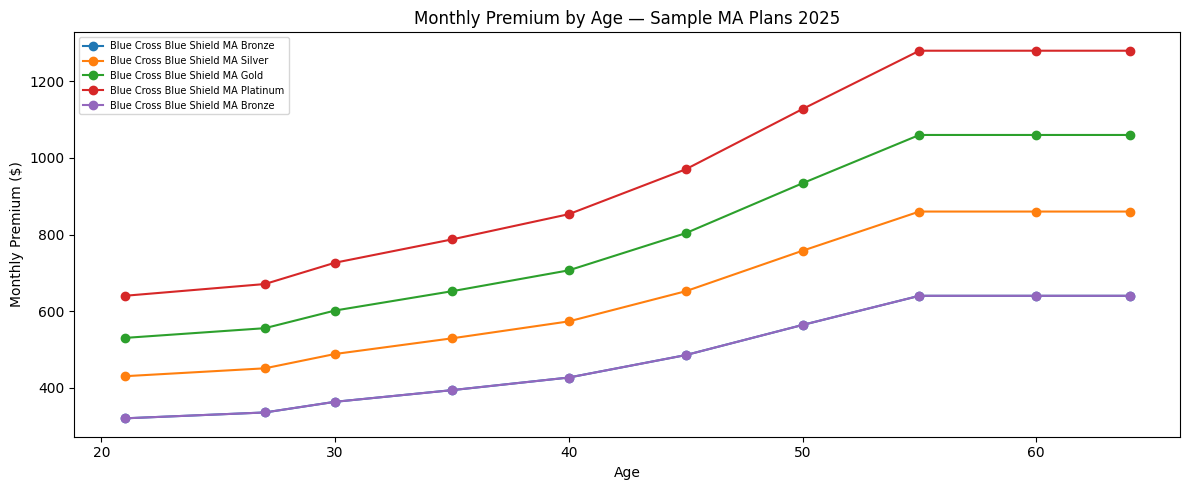

Charts saved. Run Cell 7 next.


In [ ]:
# ─── Exploratory Data Analysis and Visualization ──────────────────────────────

print("PHASE 3b — EXPLORATORY DATA ANALYSIS")
print("-" * 45)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Massachusetts Health Insurance Plans — 2025", fontsize=14, fontweight="bold")

# Plans by Carrier
if "carrier_name" in df_master.columns:
    cc_counts = df_master["carrier_name"].value_counts()
    axes[0].barh(cc_counts.index, cc_counts.values, color="steelblue")
    axes[0].set_title("Plans by Carrier")
    axes[0].set_xlabel("Count")

# Plans by Metal Tier
if "metal_tier" in df_master.columns:
    order  = ["Platinum", "Gold", "Silver", "Bronze", "Catastrophic"]
    colors = ["#9b59b6", "#f39c12", "#95a5a6", "#cd7f32", "#e74c3c"]
    tc     = df_master["metal_tier"].value_counts().reindex(order).dropna()
    axes[1].bar(tc.index, tc.values, color=colors[:len(tc)])
    axes[1].set_title("Plans by Metal Tier")

# Plan Type Distribution
if "plan_type" in df_master.columns:
    pt = df_master["plan_type"].value_counts()
    axes[2].pie(pt.values, labels=pt.index, autopct="%1.1f%%",
                colors=["#3498db", "#2ecc71", "#e74c3c", "#f39c12"])
    axes[2].set_title("Plan Type Distribution")

plt.tight_layout()
plt.savefig(f"{PATHS['processed']}/plans_overview.png", dpi=150)
plt.show()

# ConnectorCare Copay Heatmap
plt.figure(figsize=(14, 5))
cc_heat = df_cc.set_index("plan_type")[[
    "pcp", "specialist", "er", "urgent_care", "outpatient_surgery",
    "inpatient", "imaging", "rx_generic", "rx_pref_brand", "rx_specialty"
]]
sns.heatmap(cc_heat, annot=True, fmt=".0f", cmap="YlOrRd", linewidths=0.5)
plt.title("ConnectorCare Copays — MA Health Connector 2025 (Table 4)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(f"{PATHS['processed']}/connectorcare_heatmap.png", dpi=150)
plt.show()

# Monthly Premium by Age — Sample Plans
age_cols = [c for c in df_master.columns if c.startswith("premium_age")]
if age_cols:
    plt.figure(figsize=(12, 5))
    ages = [int(c.replace("premium_age", "")) for c in age_cols]
    for _, row in df_master.dropna(subset=age_cols[:1]).head(5).iterrows():
        premiums = [row[c] for c in age_cols]
        plt.plot(ages, premiums, marker="o",
                 label=f"{row.get('carrier_name', '')} {row.get('metal_tier', '')}")
    plt.title("Monthly Premium by Age — Sample MA Plans 2025")
    plt.xlabel("Age")
    plt.ylabel("Monthly Premium ($)")
    plt.legend(fontsize=7)
    plt.tight_layout()
    plt.savefig(f"{PATHS['processed']}/premium_by_age.png", dpi=150)
    plt.show()

print("Charts saved. Run Cell 7 next.")

### Cell 7 - Build RAG Text Chunks

In [ ]:
# ─── Build RAG Text Chunks ────────────────────────────────────────────────────
# Converts each plan row and ConnectorCare entry into a structured text chunk
# for use in the FAISS vector index and RAG retrieval pipeline.

import json

print("Building RAG chunks...")


def plan_to_text(row):
    """Convert a plan DataFrame row into a structured plain-text chunk."""

    def v(col, default="N/A"):
        val = row.get(col, default)
        return default if pd.isna(val) else str(val)

    def dollar(col, default="See plan"):
        val = row.get(col)
        if val is None or pd.isna(val) or str(val).strip() in ("", "nan", "Not Covered"):
            return default
        s = str(val).strip()
        return s if s.startswith("$") else f"${s}"

    age_cols_present = [
        f"premium_age{a}" for a in [21, 27, 30, 35, 40, 45, 50, 55, 60, 64]
        if f"premium_age{a}" in row.index
    ]
    premium_lines = "\n".join([
        f"  Age {a.replace('premium_age', '')}: {dollar(a)}"
        for a in age_cols_present
    ])

    # Pre-compute dollar values to avoid single-quote conflicts inside f-string
    pcp       = dollar("copay_primary_care_visit_to_treat_an_injury_or_illness")
    spec      = dollar("copay_specialist_visit")
    er        = dollar("copay_emergency_room_services")
    urg       = dollar("copay_urgent_care_centers_or_facilities")
    mh        = dollar("copay_mental_behavioral_health_outpatient_services")
    inp       = dollar("copay_inpatient_hospital_services_e_g_hospital_stay")
    img       = dollar("copay_imaging_ct_pet_scans_mris")
    lab       = dollar("copay_laboratory_outpatient_and_professional_services")
    gen       = dollar("copay_generic_drugs")
    pref      = dollar("copay_preferred_brand_drugs")
    nonpref   = dollar("copay_non_preferred_brand_drugs")
    specialty = dollar("copay_specialty_drugs")
    eye       = dollar("copay_routine_eye_exam_adult")
    cc_compat = "Yes" if str(row.get("connectorcare_compatible", "")).upper() == "TRUE" else "No"
    premiums  = premium_lines if premium_lines else "  See mahealthconnector.org"

    return f"""
PLAN: {v("plan_name")}
Carrier: {v("carrier_name")} | Plan ID: {v("PlanId")}
Plan Type: {v("plan_type")} | Metal Tier: {v("metal_tier")}
State: Massachusetts | Plan Year: 2025
HSA Eligible: {v("hsa_eligible")} | Referral Required: {v("referral_required")}
ConnectorCare Compatible: {cc_compat}

MONTHLY PREMIUMS (unsubsidized):
{premiums}
Note: Premiums identical for male and female (ACA §2701)

COST SHARING:
  Primary Care   : {pcp}
  Specialist     : {spec}
  Emergency Room : {er}
  Urgent Care    : {urg}
  Mental Health  : {mh}
  Inpatient Hosp : {inp}
  Imaging        : {img}
  Lab Services   : {lab}
  Preventive Care: $0 (ACA mandate)

PRESCRIPTIONS:
  Generic        : {gen}
  Preferred Brand: {pref}
  Non-Preferred  : {nonpref}
  Specialty      : {specialty}
  GLP-1 Obesity  : Not covered (all MA carriers Jan 2026)
  Insulin Generic: $0 (PACT Act) | Insulin Brand: $25 max (PACT Act)

ADDITIONAL:
  Maternity/Prenatal : Covered (ACA EHB)
  Pediatric Dental   : Included (ACA EHB)
  Routine Eye Exam   : {eye}
""".strip()


def cc_to_text(row):
    """Convert a ConnectorCare row into a structured plain-text chunk."""
    return (
        f"CONNECTORCARE PLAN: {row['plan_type']} — Income {row['fpl_range']} FPL\n"
        f"Source: MA Health Connector ConnectorCare Overview 2025, Table 4\n"
        f"All ConnectorCare plans: $0 deductible | Benefits same across all carriers\n"
        f"Eligibility: Income {row['fpl_range']} FPL | MA resident\n\n"
        f"PREMIUMS & OOP:\n"
        f"  Lowest Premium: ${row['premium_min']}/mo | Deductible: $0\n"
        f"  Medical OOP (Ind/Fam): ${row['oop_medical_ind']} / ${row['oop_medical_fam']}\n"
        f"  Rx OOP (Ind/Fam): ${row['oop_rx_ind']} / ${row['oop_rx_fam']}\n\n"
        f"COPAYS:\n"
        f"  PCP: $0 | Preventive: $0 | Mental Health: $0 | Lab/X-Ray: $0\n"
        f"  Specialist: ${row['specialist']} | Urgent Care: ${row['urgent_care']}\n"
        f"  ER: ${row['er']} | Outpatient Surgery: ${row['outpatient_surgery']}\n"
        f"  Inpatient: ${row['inpatient']} | Imaging: ${row['imaging']}\n"
        f"  Rx Generic: ${row['rx_generic']} | Preferred Brand: ${row['rx_pref_brand']}\n"
        f"  Non-Preferred: ${row['rx_nonpref_brand']} | Specialty: ${row['rx_specialty']}\n"
        f"  Chronic Condition Meds (asthma, diabetes, hypertension): $0"
    )


# ─── Build Chunks List ─────────────────────────────────────────────────────────
chunks = []

for idx, row in df_master.iterrows():
    chunks.append({
        "chunk_id":   f"plan_{row.get('PlanId', idx)}",
        "chunk_type": "plan",
        "text":       plan_to_text(row),
        "metadata": {
            "plan_id":       str(row.get("PlanId", "")),
            "carrier":       str(row.get("carrier_name", "")),
            "plan_name":     str(row.get("plan_name", "")),
            "plan_type":     str(row.get("plan_type", "")),
            "metal_tier":    str(row.get("metal_tier", "")),
            "hsa_eligible":  str(row.get("hsa_eligible", "")),
            "connectorcare": str(row.get("connectorcare_compatible", "")),
            "state":         "MA",
            "plan_year":     "2025",
        }
    })

for _, row in df_cc.iterrows():
    chunks.append({
        "chunk_id":   f"cc_{row['plan_type'].replace(' ', '_')}",
        "chunk_type": "connectorcare",
        "text":       cc_to_text(row),
        "metadata": {
            "plan_type": row["plan_type"],
            "fpl_range": row["fpl_range"],
            "state":     "MA",
            "plan_year": "2025",
        }
    })

# ─── Save Chunks to Disk ───────────────────────────────────────────────────────
chunks_path = f"{PATHS['processed']}/chunks.jsonl"
with open(chunks_path, "w") as f:
    for chunk in chunks:
        f.write(json.dumps(chunk) + "\n")

n_plans = sum(1 for c in chunks if c["chunk_type"] == "plan")
n_cc    = sum(1 for c in chunks if c["chunk_type"] == "connectorcare")
print(f"  {len(chunks)} chunks saved ({n_plans} plan chunks + {n_cc} ConnectorCare chunks).")

Building RAG chunks...
  37 chunks saved (30 plan chunks + 7 ConnectorCare chunks).


### Cell 8 - Generate Embeddings and Build FAISS Index

In [ ]:
# ─── Generate Embeddings and Build FAISS Index ────────────────────────────────
# Encodes all text chunks using a sentence transformer model and stores them
# in a FAISS index for fast semantic similarity search at query time.

from sentence_transformers import SentenceTransformer
import faiss

print("Building FAISS index (downloads ~90MB on first run)...")

embedder   = SentenceTransformer("all-MiniLM-L6-v2")
texts      = [c["text"] for c in chunks]
embeddings = []

for i in range(0, len(texts), 32):
    batch = embedder.encode(texts[i:i+32], show_progress_bar=False)
    embeddings.extend(batch)
    print(f"\r  Embedded {min(i+32, len(texts))}/{len(texts)} chunks", end="")

embeddings = np.array(embeddings).astype("float32")
faiss.normalize_L2(embeddings)

index = faiss.IndexFlatIP(embeddings.shape[1])
index.add(embeddings)

faiss.write_index(index, f"{PATHS['vectorstore']}/index.faiss")
with open(f"{PATHS['vectorstore']}/chunks_metadata.pkl", "wb") as f:
    pickle.dump(chunks, f)

print(f"\n  FAISS index built: {index.ntotal} vectors saved.")

Building FAISS index (downloads ~90MB on first run)...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

  Embedded 37/37 chunks
  FAISS index built: 37 vectors saved.


### Cell 9 - Feature Extraction and XGBoost Re-Ranker

In [ ]:
# ─── Feature Extraction and XGBoost Re-Ranker ────────────────────────────────
# Defines a feature extraction function for query-chunk pairs and trains an
# XGBoost re-ranker on labeled queries to improve retrieval ranking.

from xgboost import XGBRanker

# ─── Feature Extraction ───────────────────────────────────────────────────────

def extract_features(query, chunk, faiss_score):
    """Extract query-chunk relevance features for re-ranking."""
    text = chunk.get("text", "").lower()
    meta = chunk.get("metadata", {})
    q    = query.lower()
    q_w  = set(q.split())
    t_w  = set(text.split())

    tiers    = ["bronze", "silver", "gold", "platinum", "catastrophic"]
    carriers = ["blue cross", "bcbs", "harvard pilgrim", "tufts", "fallon",
                "health new england", "hne", "wellsense", "mass general", "mgb", "unitedhealthcare"]

    q_tier    = next((t for t in tiers    if t in q), None)
    q_carrier = next((c for c in carriers if c in q), None)
    q_type    = next((p for p in ["hmo", "ppo", "epo"] if p in q), None)

    return [
        float(faiss_score),
        len(q_w & t_w) / max(len(q_w), 1),
        1.0 if q_tier    and q_tier    == meta.get("metal_tier", "").lower() else 0.0,
        1.0 if q_carrier and q_carrier in  meta.get("carrier",   "").lower() else 0.0,
        1.0 if q_type    and q_type    == meta.get("plan_type",  "").lower() else 0.0,
        1.0 if meta.get("chunk_type") == "connectorcare" else 0.0,
        1.0 if any(k in q for k in ["connectorcare", "subsidy", "fpl", "income", "afford"]) else 0.0,
        min(len(text) / 2000, 1.0),
        1.0 if any(k in q for k in ["premium", "cost", "price", "monthly", "afford"]) else 0.0,
        1.0 if re.search(r"\b\d{2}\b", q) else 0.0,
        float(meta.get("avg_feedback_score", 0.5)),
    ]

FEATURE_NAMES = [
    "faiss_score", "keyword_overlap", "tier_match", "carrier_match",
    "type_match", "is_connectorcare", "cc_query", "chunk_length",
    "premium_query", "has_age", "feedback_score",
]

# ─── Training Queries ─────────────────────────────────────────────────────────
# Format: (query, relevant_tier, relevant_carrier, is_connectorcare_query)

TRAINING_QUERIES = [
    ("Specialist visit copay Silver plan",        "silver",   None,               False),
    ("Monthly premium 40 year old Gold plan",     "gold",     None,               False),
    ("What is ConnectorCare do I qualify",        None,       None,               True),
    ("Compare Bronze HMO plans Massachusetts",    "bronze",   None,               False),
    ("Harvard Pilgrim Silver plan benefits",      "silver",   "harvard pilgrim",  False),
    ("What does Platinum plan cover",             "platinum", None,               False),
    ("BCBS Gold plan cost age 30",                "gold",     "blue cross",       False),
    ("Tufts Bronze plan deductible",              "bronze",   "tufts",            False),
    ("HSA eligible plans Massachusetts",          None,       None,               False),
    ("UnitedHealthcare ER copay",                 None,       "unitedhealthcare", False),
    ("ConnectorCare 250 percent FPL income",      None,       None,               True),
    ("Fallon Health Gold plans",                  "gold",     "fallon",           False),
    ("Prescription drug coverage Silver",         "silver",   None,               False),
    ("WellSense mental health benefits",          None,       "wellsense",        False),
    ("Health insurance cost 60 year old",         None,       None,               False),
]

# ─── Build Training Data ──────────────────────────────────────────────────────
X, y, groups = [], [], []

for query, rel_tier, rel_carrier, is_cc in TRAINING_QUERIES:
    gX, gy = [], []
    for chunk in chunks:
        meta  = chunk.get("metadata", {})
        feats = extract_features(query, chunk, 0.5)
        gX.append(feats)

        label = 0
        if is_cc and meta.get("chunk_type") == "connectorcare":
            label = 2
        elif rel_tier and rel_tier == meta.get("metal_tier", "").lower():
            label = 2 if (rel_carrier and rel_carrier in meta.get("carrier", "").lower()) else 1
        elif rel_carrier and rel_carrier in meta.get("carrier", "").lower():
            label = 1
        gy.append(label)

    X.extend(gX)
    y.extend(gy)
    groups.append(len(gX))

X      = np.array(X)
y      = np.array(y)
groups = np.array(groups)

# ─── Train XGBoost Re-Ranker ──────────────────────────────────────────────────
xgb_model = XGBRanker(
    objective="rank:pairwise",
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    tree_method="hist",
    eval_metric="ndcg",
)
xgb_model.fit(X, y, group=groups, verbose=False)

model_path = f"{PATHS['models']}/xgb_reranker.pkl"
with open(model_path, "wb") as f:
    pickle.dump(xgb_model, f)

print(f"XGBoost re-ranker trained and saved to: {model_path}")
print("\nTop Features by Importance:")
for name, imp in sorted(zip(FEATURE_NAMES, xgb_model.feature_importances_),
                         key=lambda x: -x[1])[:5]:
    print(f"  {name:<22} {imp:.4f}")

XGBoost re-ranker trained and saved to: /content/drive/MyDrive/Health_Benefits_Navigator/models/xgb_reranker.pkl

Top Features by Importance:
  tier_match             0.5339
  carrier_match          0.3766
  keyword_overlap        0.0427
  premium_query          0.0258
  chunk_length           0.0210


### Cell 10 - RAG Pipeline with Mistral AI

In [ ]:
# ─── RAG Pipeline with Mistral AI ─────────────────────────────────────────────
# Connects to Mistral AI and defines the full retrieval-augmented generation
# pipeline: query encoding, semantic search, XGBoost re-ranking, and answer
# generation. Includes a feedback logging utility.

!pip install mistralai -q

from mistralai import Mistral
from google.colab import userdata

# ─── Connect to Mistral ───────────────────────────────────────────────────────
try:
    MISTRAL_API_KEY = userdata.get("MISTRAL_API_KEY")
    print("Mistral API key loaded from Colab Secrets.")
except Exception:
    MISTRAL_API_KEY = "paste_your_key_here"
    print("Warning: using hardcoded key. Add MISTRAL_API_KEY to Colab Secrets for security.")

mistral_client = Mistral(api_key=MISTRAL_API_KEY)
test = mistral_client.chat.complete(
    model="mistral-small-latest",
    messages=[{"role": "user", "content": "Say hello in one sentence."}],
    max_tokens=50,
)
print(f"Mistral connected: {test.choices[0].message.content.strip()}")

# ─── Pipeline Configuration ───────────────────────────────────────────────────
TOP_K = 15   # Number of candidates retrieved from FAISS
TOP_N = 5    # Number of chunks passed to the LLM after re-ranking

SYSTEM_PROMPT = (
    "You are a helpful Massachusetts health insurance benefits navigator. "
    "Answer questions about MA health insurance plans for plan year 2025. "
    "Use only the context provided. If not found, direct to mahealthconnector.org "
    "or 1-877-623-6765. Always mention plan name and carrier. "
    "Premiums are identical for all genders (ACA §2701). "
    "Mention ConnectorCare if the user asks about cost assistance."
)

# ─── Pipeline Functions ───────────────────────────────────────────────────────

def encode_query(query, filters=None):
    """Enrich query with user filter context before embedding."""
    if not filters:
        return query
    ctx = []
    if filters.get("age"):
        ctx.append(f"age {filters['age']}")
    if filters.get("tier") and filters["tier"] != "Any":
        ctx.append(filters["tier"])
    if filters.get("carrier") and filters["carrier"] != "Any":
        ctx.append(filters["carrier"])
    if filters.get("connectorcare"):
        ctx.append("ConnectorCare eligible")
    return f"[{', '.join(ctx)}] {query}" if ctx else query


def semantic_search(query_text, k=TOP_K):
    """Retrieve top-k chunks from FAISS by cosine similarity."""
    q_emb = embedder.encode([query_text]).astype("float32")
    faiss.normalize_L2(q_emb)
    scores, indices = index.search(q_emb, k)
    return [
        (chunks[i], float(s))
        for s, i in zip(scores[0], indices[0])
        if i < len(chunks)
    ]


def rerank(query, candidates, n=TOP_N):
    """Re-rank FAISS candidates using the XGBoost model."""
    if not candidates:
        return []
    X_re   = np.array([extract_features(query, c, s) for c, s in candidates])
    scores = xgb_model.predict(X_re)
    ranked = sorted(zip(candidates, scores), key=lambda x: x[1], reverse=True)
    return [c for (c, _), _ in ranked[:n]]


def generate_answer(query, top_chunks):
    """Generate a natural language answer using Mistral with retrieved context."""
    context  = "\n\n---\n\n".join(c["text"] for c in top_chunks)
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user",   "content": f"Context:\n{context[:4000]}\n\nQuestion: {query}"}
    ]
    resp = mistral_client.chat.complete(
        model="mistral-small-latest",
        messages=messages,
        max_tokens=512,
        temperature=0.1,
    )
    return resp.choices[0].message.content.strip()


def rag_query(question, filters=None):
    """End-to-end RAG pipeline: encode, retrieve, re-rank, generate."""
    enriched   = encode_query(question, filters)
    candidates = semantic_search(enriched)
    top_chunks = rerank(question, candidates)
    answer     = generate_answer(question, top_chunks)
    return {"answer": answer, "top_chunks": top_chunks, "enriched_query": enriched}


# ─── Feedback Logging ─────────────────────────────────────────────────────────
FEEDBACK_PATH = f"{PATHS['feedback']}/feedback_log.csv"
FEEDBACK_COLS = ["timestamp", "query", "answer", "rating", "chunk_ids", "comment"]

def log_feedback(query, answer, rating, top_chunks, comment=""):
    """Append a feedback entry to the feedback log CSV."""
    row = {
        "timestamp": datetime.now().isoformat(),
        "query":     query,
        "answer":    answer[:300],
        "rating":    rating,
        "chunk_ids": json.dumps([c["metadata"].get("plan_id", c["chunk_id"]) for c in top_chunks]),
        "comment":   comment,
    }
    exists = os.path.exists(FEEDBACK_PATH)
    with open(FEEDBACK_PATH, "a", newline="") as f:
        w = csv.DictWriter(f, fieldnames=FEEDBACK_COLS)
        if not exists:
            w.writeheader()
        w.writerow(row)
    print(f"Feedback logged: {rating}/5 stars.")

print("RAG pipeline ready.")

Mistral API key loaded from Colab Secrets.
Mistral connected: Hello! 😊
RAG pipeline ready.


### Cell 11 - RAG Pipeline Testing


In [ ]:
# ─── RAG Pipeline Testing ─────────────────────────────────────────────────────
# Runs a set of representative queries through the full RAG pipeline to verify
# end-to-end functionality before launching the Streamlit app.

test_questions = [
    "What is the copay for a specialist on a Silver HMO plan?",
    "What is ConnectorCare and who qualifies?",
    "Which plans are HSA eligible in Massachusetts?",
    "What is the ER copay on a Bronze plan?",
    "Compare Harvard Pilgrim and BCBS Gold plans",
]

for q in test_questions:
    print(f"Q: {q}")
    result = rag_query(q)
    print(f"A: {result['answer'][:250]}...")
    print("-" * 55)

Q: What is the copay for a specialist on a Silver HMO plan?
A: For **Silver HMO plans** in Massachusetts for plan year 2025, the specialist copay varies by carrier:

- **HNE HMO Silver** (Health New England): **$50**
- **MGB Health Plan Silver HMO** (Mass General Brigham): **$50**
- **WellSense Health Plan Silve...
-------------------------------------------------------
Q: What is ConnectorCare and who qualifies?
A: **ConnectorCare** is a Massachusetts health insurance program that offers **cost assistance** (subsidies) to help lower monthly premiums and out-of-pocket costs for eligible individuals and families. It is designed to make health coverage more afford...
-------------------------------------------------------
Q: Which plans are HSA eligible in Massachusetts?
A: In Massachusetts for plan year 2025, the following plans are **HSA eligible**:

1. **Harvard Pilgrim HMO Saver (Bronze)**
   - Carrier: Harvard Pilgrim
   - Plan ID: 10100MA00080001-00

2. **WellSense Health Plan Bron

### Cell 12 - Streamlit App

In [ ]:
# ─── Write Streamlit App to Disk ──────────────────────────────────────────────
# Writes the full Streamlit app as app.py to Google Drive.
# The app provides a chat interface with sidebar filters, RAG-powered answers,
# source attribution, and a star-rating feedback system.


from google.colab import userdata

MISTRAL_KEY = userdata.get("MISTRAL_API_KEY")
NGROK_TOKEN = userdata.get("NGROK_AUTH_TOKEN")

if not MISTRAL_KEY:
    raise ValueError("MISTRAL_API_KEY not found in Colab Secrets.")
if not NGROK_TOKEN:
    raise ValueError("NGROK_AUTH_TOKEN not found in Colab Secrets.")

app_code = f'''
import os, json, pickle, csv, re
import numpy as np
import pandas as pd
import faiss
import streamlit as st
from sentence_transformers import SentenceTransformer
from mistralai import Mistral
from datetime import datetime

BASE         = "/content/drive/MyDrive/Health_Benefits_Navigator"
VECTORSTORE  = f"{{BASE}}/data/vectorstore"
MODELS       = f"{{BASE}}/models"
MISTRAL_API_KEY = "{MISTRAL_KEY}"

# ─── System prompt instructs Mistral to return JSON with answer + ranked_plans ─
SYSTEM_PROMPT = (
    "You are a Massachusetts health insurance benefits navigator for plan year 2025. "
    "Use ONLY the context provided. If info is missing, direct to mahealthconnector.org "
    "or 1-877-623-6765. Always mention plan name and carrier. "
    "Premiums are identical for all genders (ACA §2701). "
    "Mention ConnectorCare if the user asks about cost assistance. "
    "Respond ONLY with a valid JSON object — no markdown, no backticks — with this structure: "
    "{{\\\"answer\\\": \\\"<narrative recommendation>\\\", "
    "\\\"ranked_plans\\\": [{{\\\"rank\\\": 1, \\\"plan_name\\\": \\\"\\\", \\\"carrier\\\": \\\"\\\", "
    "\\\"plan_id\\\": \\\"\\\", \\\"metal_tier\\\": \\\"\\\", \\\"plan_type\\\": \\\"\\\", "
    "\\\"monthly_premium\\\": \\\"\\\", \\\"deductible\\\": \\\"\\\", "
    "\\\"primary_care_copay\\\": \\\"\\\", \\\"specialist_copay\\\": \\\"\\\", "
    "\\\"gym_benefit\\\": \\\"\\\", \\\"connector_care\\\": \\\"\\\", "
    "\\\"why_ranked_here\\\": \\\"\\\"}}]}}"
)


@st.cache_resource
def load_resources():
    embedder = SentenceTransformer("all-MiniLM-L6-v2")
    index    = faiss.read_index(f"{{VECTORSTORE}}/index.faiss")
    with open(f"{{VECTORSTORE}}/chunks_metadata.pkl", "rb") as f:
        chunks = pickle.load(f)
    with open(f"{{MODELS}}/xgb_reranker.pkl", "rb") as f:
        xgb = pickle.load(f)
    return embedder, index, chunks, xgb, Mistral(api_key=MISTRAL_API_KEY)

embedder, index, chunks, xgb_model, mistral_client = load_resources()
TOP_K, TOP_N = 15, 5


def extract_features(query, chunk, score):
    text = chunk.get("text", "").lower()
    meta = chunk.get("metadata", {{}})
    q    = query.lower()
    q_w  = set(q.split())
    t_w  = set(text.split())
    tiers    = ["bronze", "silver", "gold", "platinum", "catastrophic"]
    carriers = ["blue cross", "bcbs", "harvard pilgrim", "tufts", "fallon",
                "health new england", "hne", "wellsense", "mass general", "mgb", "unitedhealthcare"]
    q_tier    = next((t for t in tiers    if t in q), None)
    q_carrier = next((c for c in carriers if c in q), None)
    q_type    = next((p for p in ["hmo", "ppo", "epo"] if p in q), None)
    return [
        float(score),
        len(q_w & t_w) / max(len(q_w), 1),
        1.0 if q_tier    and q_tier    == meta.get("metal_tier", "").lower() else 0.0,
        1.0 if q_carrier and q_carrier in  meta.get("carrier",   "").lower() else 0.0,
        1.0 if q_type    and q_type    == meta.get("plan_type",  "").lower() else 0.0,
        1.0 if meta.get("chunk_type") == "connectorcare" else 0.0,
        1.0 if any(k in q for k in ["connectorcare", "subsidy", "fpl", "income", "afford"]) else 0.0,
        min(len(text) / 2000, 1.0),
        1.0 if any(k in q for k in ["premium", "cost", "price", "monthly", "afford"]) else 0.0,
        1.0 if re.search(r"\\\\b\\\\d{{2}}\\\\b", q) else 0.0,
        0.5,
    ]


def rag(question, filters=None):
    """Run RAG pipeline. Returns dict with answer + ranked_plans + top_chunks."""
    enriched = question
    if filters:
        ctx = []
        if filters.get("age"):          ctx.append(f"age {{filters['age']}}")
        if filters.get("tier")    and filters["tier"]    != "Any": ctx.append(filters["tier"])
        if filters.get("carrier") and filters["carrier"] != "Any": ctx.append(filters["carrier"])
        if filters.get("connectorcare"): ctx.append("ConnectorCare eligible")
        if ctx: enriched = f"[{{', '.join(ctx)}}] {{question}}"

    q_emb = embedder.encode([enriched]).astype("float32")
    faiss.normalize_L2(q_emb)
    scores, idxs = index.search(q_emb, TOP_K)
    candidates   = [(chunks[i], float(s)) for s, i in zip(scores[0], idxs[0]) if i < len(chunks)]
    X_re         = np.array([extract_features(question, c, s) for c, s in candidates])
    ranked       = sorted(zip(candidates, xgb_model.predict(X_re)), key=lambda x: x[1], reverse=True)
    top_chunks   = [c for (c, _), _ in ranked[:TOP_N]]

    context = "\\n\\n---\\n\\n".join(
        f"[Plan: {{c.get('metadata',{{}}).get('plan_id','?')}}]\\n{{c['text']}}"
        for c in top_chunks
    )

    user_prompt = (
        f"Context:\\n{{context[:5000]}}\\n\\n"
        f"Question: {{question}}\\n\\n"
        "Return ONLY a JSON object (no backticks, no markdown) with keys: "
        "'answer' (narrative string) and 'ranked_plans' (array of all plans found, "
        "ranked best to worst for this user, each with: rank, plan_name, carrier, plan_id, "
        "metal_tier, plan_type, monthly_premium, deductible, primary_care_copay, "
        "specialist_copay, gym_benefit, connector_care, why_ranked_here)."
    )

    messages = [
        {{"role": "system", "content": SYSTEM_PROMPT}},
        {{"role": "user",   "content": user_prompt}}
    ]
    resp = mistral_client.chat.complete(
        model="mistral-small-latest", messages=messages, max_tokens=1200, temperature=0.1
    )
    raw = resp.choices[0].message.content.strip()
    raw_clean = re.sub(r"^```(?:json)?|```$", "", raw, flags=re.MULTILINE).strip()
    try:
        result = json.loads(raw_clean)
    except json.JSONDecodeError:
        result = {{"answer": raw, "ranked_plans": []}}
    result["top_chunks"] = top_chunks
    return result


def render_table(ranked_plans):
    """Render a plan comparison table + ranking rationale."""
    if not ranked_plans:
        return
    col_map = {{
        "rank": "Rank", "plan_name": "Plan Name", "carrier": "Carrier",
        "plan_id": "Plan ID", "metal_tier": "Tier", "plan_type": "Type",
        "monthly_premium": "Premium/mo", "deductible": "Deductible",
        "primary_care_copay": "PCP Copay", "specialist_copay": "Specialist",
        "gym_benefit": "Gym Benefit", "connector_care": "ConnectorCare",
        "why_ranked_here": "Why This Rank?",
    }}
    df = pd.DataFrame(ranked_plans)
    existing = [c for c in col_map if c in df.columns]
    df = df[existing].rename(columns=col_map)

    st.markdown("#### 📊 Plan Comparison Table *(ranked best → worst for your query)*")
    st.dataframe(df, use_container_width=True, hide_index=True)

    st.markdown("**📌 Ranking Rationale**")
    for _, row in df.iterrows():
        st.markdown(
            f"- **#{{int(row['Rank'])}} {{row['Plan Name']}}** "
            f"({{row.get('Tier','?')}}, {{row.get('Type','?')}}): "
            f"{{row['Why This Rank?']}}"
        )


# ─── App Layout ────────────────────────────────────────────────────────────────
st.set_page_config(page_title="MA Health Navigator", page_icon="🏥", layout="wide")
st.markdown("""
    <style>
        .stApp {{
            background-color: #000000;
        }}
        section[data-testid="stMain"] {{
            background-color: #0a1f3f;
        }}
        div[data-testid="stVerticalBlockBorderWrapper"] {{
            background-color: #0D2B56;
            border: 1px solid #C0C0C0 !important;
            border-radius: 10px;
        }}
        .stSlider > div > div > div > div {{
            background-color: #C0C0C0;
        }}
        div[data-testid="stCaption"] {{
            color: #a0b4cc;
        }}
    </style>
""", unsafe_allow_html=True)
st.title("🏥 Massachusetts Health Benefits Navigator")

# ── TOP FILTER BAR ─────────────────────────────────────────────────────────────
st.markdown("""
    <style>
        div[data-testid="stVerticalBlock"]:has(> div[data-testid="stVerticalBlockBorderWrapper"]) {{
            background-color: #1e3a5f;
            padding: 16px 20px;
            border-radius: 10px;
        }}
    </style>
""", unsafe_allow_html=True)

with st.container(border=True):
    st.markdown('<p style="color: #a8c4e0; font-size: 12px; font-weight: 600; letter-spacing: 0.08em; margin: 0 0 8px 0;">🔎 FILTER PLANS</p>', unsafe_allow_html=True)
    col1, col2, col3, col4, col5 = st.columns([1.2, 1.0, 1.3, 1.8, 1.2])
    with col1:
        age = st.slider("Your Age", 18, 64, 30)
    with col2:
        gender = st.radio("Gender ⓘ", ["Female", "Male"], horizontal=True,
                          help="Premiums identical for all genders (ACA §2701)")
    with col3:
        tier = st.selectbox("Metal Tier",
                            ["Any", "Platinum", "Gold", "Silver", "Bronze", "Catastrophic"])
    with col4:
        carrier = st.selectbox("Carrier",
                               ["Any", "Blue Cross Blue Shield MA", "Harvard Pilgrim",
                                "Tufts Health", "Fallon Health", "Health New England",
                                "WellSense", "Mass General Brigham", "UnitedHealthcare"])
    with col5:
        cc = st.checkbox("ConnectorCare eligible ⓘ",
                         help="Subsidized plans for households up to 500% FPL")
#st.divider()
#st.caption("LLM: Mistral AI  |  Data: CMS PUF 2025")

# ── FEEDBACK LOG (unchanged) ───────────────────────────────────────────────────
FEEDBACK_LOG = BASE + "/data/feedback/feedback_log.csv"

def log_feedback(query, answer, rating, top_chunks):
    row = {{
        "timestamp": datetime.now().isoformat(),
        "query":     query,
        "answer":    answer[:300],
        "rating":    rating,
        "chunk_ids": json.dumps([c.get("chunk_id","") for c in top_chunks]),
        "comment":   "",
    }}
    exists = os.path.exists(FEEDBACK_LOG)
    with open(FEEDBACK_LOG, "a", newline="") as f:
        w = csv.DictWriter(f, fieldnames=row.keys())
        if not exists:
            w.writeheader()
        w.writerow(row)

# ─── Session state ─────────────────────────────────────────────────────────────
if "messages"       not in st.session_state: st.session_state.messages       = []
if "pending_prompt" not in st.session_state: st.session_state.pending_prompt = None


def process_prompt(prompt):
    """Shared handler for both typed input and suggestion buttons."""
    st.session_state.messages.append({{"role": "user", "content": prompt}})
    with st.chat_message("user"):
        st.markdown(prompt)
    with st.chat_message("assistant"):
        with st.spinner("🔍 Searching plans with Mistral AI…"):
            filters = {{"age": age, "gender": gender, "tier": tier,
                        "carrier": carrier, "connectorcare": cc}}
            result = rag(prompt, filters)
        answer       = result.get("answer", "No answer generated.")
        ranked_plans = result.get("ranked_plans", [])
        top_chunks   = result.get("top_chunks", [])
        st.markdown(answer)
        render_table(ranked_plans)
        if top_chunks:
            with st.expander("📚 Sources"):
                for c in top_chunks:
                    m = c.get("metadata", {{}})
                    st.caption(
                        f"• {{m.get('carrier', '?')}} — "
                        f"{{m.get('plan_name', m.get('plan_id', '?'))}} | CMS PUF 2025"
                    )
    # Store ranked_plans so table re-renders on scroll-back
    st.session_state.messages.append({{
        "role": "assistant", "content": answer, "ranked_plans": ranked_plans
    }})
    # Silently log feedback (auto-rating based on result quality; hidden from users)
    log_feedback(prompt, answer, rating=None, top_chunks=top_chunks)


# ─── Suggestion buttons (only shown when chat is empty) ────────────────────────
if not st.session_state.messages:
    st.markdown("**💡 Try asking:**")
    suggestions = [
        f"What is the premium for a {{age}}-year-old on a Silver HMO?",
        "What is ConnectorCare and how do I qualify?",
        "Compare Harvard Pilgrim and BCBS Gold plans",
        "Which plans are HSA eligible in Massachusetts?",
        "What is the ER copay on a Bronze plan?",
        "What does a Platinum plan cover vs Gold?",
    ]
    cols = st.columns(2)
    for i, s in enumerate(suggestions):
        # FIX: store in pending_prompt + rerun; do NOT call rag() inside button block
        if cols[i % 2].button(s, key=f"sug_{{i}}", use_container_width=True):
            st.session_state.pending_prompt = s
            st.rerun()

# ─── Re-render existing chat history ──────────────────────────────────────────
for msg in st.session_state.messages:
    with st.chat_message(msg["role"]):
        st.markdown(msg["content"])
        if msg["role"] == "assistant" and msg.get("ranked_plans"):
            render_table(msg["ranked_plans"])

# ─── Handle pending suggestion (runs after rerun, outside button block) ────────
if st.session_state.pending_prompt:
    prompt = st.session_state.pending_prompt
    st.session_state.pending_prompt = None   # clear BEFORE processing
    process_prompt(prompt)

# ─── Handle typed chat input ───────────────────────────────────────────────────
if prompt := st.chat_input("Ask about Massachusetts health insurance…"):
    process_prompt(prompt)
'''

app_path = f"{PATHS['app']}/app.py"
with open(app_path, "w") as f:
    f.write(app_code)

print(f"✅ Streamlit app written → {app_path}")

✅ Streamlit app written → /content/drive/MyDrive/Health_Benefits_Navigator/app/app.py


### Cell 13 - Launch Streamlit App via ngrok


In [ ]:
# ─── Launch Streamlit App via ngrok ───────────────────────────────────────────
# Starts the Streamlit server and exposes it publicly via an ngrok tunnel.
# Run ngrok.kill() in a new cell to stop the tunnel.

import subprocess
import time
from pyngrok import ngrok

ngrok.kill()
ngrok.set_auth_token(NGROK_TOKEN)

app_path = f"{PATHS['app']}/app.py"

subprocess.Popen(
    [
        "streamlit", "run", app_path,
        "--server.port", "8501",
        "--server.headless", "true",
        "--server.enableCORS", "false",
    ],
    stdout=subprocess.DEVNULL,
    stderr=subprocess.DEVNULL,
)

time.sleep(5)
tunnel = ngrok.connect(8501)

print("App is live at:", tunnel.public_url)
print("To stop the app, run: ngrok.kill()")

App is live at: https://freda-preseasonal-booker.ngrok-free.dev
To stop the app, run: ngrok.kill()


#Cell 14 - Model Evaluation


In [ ]:
import os, json, re, csv, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import ndcg_score
from datetime import datetime
from mistralai import Mistral
from google.colab import userdata

EVAL_DIR = f"{BASE}/evaluation"
os.makedirs(EVAL_DIR, exist_ok=True)

# Reuse already-loaded resources from your notebook:
# embedder, index, chunks, xgb_model, mistral_client
MISTRAL_API_KEY = userdata.get("MISTRAL_API_KEY")
mistral_client  = Mistral(api_key=MISTRAL_API_KEY)

print(f" Evaluation setup ready")
print(f"   Chunks     : {len(chunks)}")
print(f"   Index size : {index.ntotal}")
print(f"   Output dir : {EVAL_DIR}")


 Evaluation setup ready
   Chunks     : 37
   Index size : 37
   Output dir : /content/drive/MyDrive/Health_Benefits_Navigator/evaluation


In [ ]:
def generate_test_set(n=50):
    np.random.seed(42)
    plan_chunks = [c for c in chunks if c["chunk_type"] == "plan"]
    cc_chunks   = [c for c in chunks if c["chunk_type"] == "connectorcare"]

    # Sample mix: 80% plan questions, 20% ConnectorCare questions
    n_plans = int(n * 0.8)
    n_cc    = n - n_plans
    sampled = (
        list(np.random.choice(plan_chunks, size=min(n_plans, len(plan_chunks)), replace=False)) +
        list(np.random.choice(cc_chunks,   size=min(n_cc,    len(cc_chunks)),   replace=False))
    )

    test_set = []
    for chunk in sampled:
        meta = chunk.get("metadata", {})
        text = chunk.get("text",     "")[:1500]

        prompt = (
            "Based on this Massachusetts health insurance plan text, write ONE realistic "
            "user question and its correct short answer.\n\n"
            f"Plan text:\n{text}\n\n"
            "Respond ONLY with a JSON object: "
            "{\"question\": \"...\", \"expected_answer\": \"...\"} "
            "No markdown, no backticks."
        )
        try:
            resp = mistral_client.chat.complete(
                model="mistral-small-latest",
                messages=[{"role": "user", "content": prompt}],
                max_tokens=300, temperature=0.3
            )
            raw    = resp.choices[0].message.content.strip()
            raw    = re.sub(r"^```(?:json)?|```$", "", raw, flags=re.MULTILINE).strip()
            parsed = json.loads(raw)
            test_set.append({
                "question":        parsed["question"],
                "expected_answer": parsed["expected_answer"],
                "source_chunk_id": meta.get("plan_id") or meta.get("plan_type", "unknown"),
                "chunk_type":      chunk["chunk_type"],
                "carrier":         meta.get("carrier", ""),
                "metal_tier":      meta.get("metal_tier", ""),
            })
        except Exception as e:
            print(f" Skipped: {e}")

    df = pd.DataFrame(test_set)
    df.to_csv(f"{EVAL_DIR}/test_set.csv", index=False)
    print(f" Generated {len(df)} test questions → {EVAL_DIR}/test_set.csv")
    print(f"   Plan questions : {(df['chunk_type']=='plan').sum()}")
    print(f"   CC questions   : {(df['chunk_type']=='connectorcare').sum()}")
    return df

test_df = generate_test_set(n=50)
test_df.head(5)


# ─── CELL 3: RAG Retrieval Evaluation ─────────────────────────────────────────
# Metrics: Hit Rate @K, MRR, Mean FAISS Score

def evaluate_rag(test_df, top_k=15):
    hits, reciprocal_ranks, faiss_scores_list = [], [], []

    for _, row in test_df.iterrows():
        q        = row["question"]
        expected = str(row["source_chunk_id"])

        # Encode + search (same as your semantic_search function)
        q_emb = embedder.encode([q]).astype("float32")
        faiss.normalize_L2(q_emb)
        scores, idxs = index.search(q_emb, top_k)

        retrieved_ids = []
        for i in idxs[0]:
            if i < len(chunks):
                meta = chunks[i].get("metadata", {})
                cid  = meta.get("plan_id") or meta.get("plan_type", "")
                retrieved_ids.append(str(cid))

        # Hit Rate @K
        hits.append(int(expected in retrieved_ids))

        # MRR
        rr = 0.0
        for rank, cid in enumerate(retrieved_ids, start=1):
            if cid == expected:
                rr = 1.0 / rank
                break
        reciprocal_ranks.append(rr)
        faiss_scores_list.append(float(scores[0][0]))

    results = {
        "Hit Rate @15":    round(np.mean(hits), 4),
        "MRR":             round(np.mean(reciprocal_ranks), 4),
        "Avg FAISS Score": round(np.mean(faiss_scores_list), 4),
        "Total Questions": len(test_df),
    }

    print("\n RAG RETRIEVAL EVALUATION")
    print("─" * 40)
    for k, v in results.items():
        print(f"  {k:<22} : {v}")

    # Interpretation
    print("\n Interpretation:")
    hr = results["Hit Rate @15"]
    if hr >= 0.8:   print(" Hit Rate is strong — retrieval is finding the right chunks.")
    elif hr >= 0.6: print(" Hit Rate is moderate — consider increasing TOP_K or improving embeddings.")
    else:           print(" Hit Rate is low — check chunk quality and embedding model.")

    pd.DataFrame([results]).to_csv(f"{EVAL_DIR}/rag_eval.csv", index=False)
    return results

rag_results = evaluate_rag(test_df, top_k=15)

 Skipped: API error occurred: Status 429
{"object":"error","message":"Rate limit exceeded","type":"rate_limited","param":null,"code":"1300","raw_status_code":429}
 Generated 36 test questions → /content/drive/MyDrive/Health_Benefits_Navigator/evaluation/test_set.csv
   Plan questions : 30
   CC questions   : 6

 RAG RETRIEVAL EVALUATION
────────────────────────────────────────
  Hit Rate @15           : 0.8611
  MRR                    : 0.7265
  Avg FAISS Score        : 0.6
  Total Questions        : 36

 Interpretation:
 Hit Rate is strong — retrieval is finding the right chunks.


In [ ]:
def evaluate_reranker(test_df, top_k=15, top_n=5):
    ndcg_list, p1_list, p3_list, mrr_list = [], [], [], []
    faiss_mrr_list = []  # baseline comparison

    for _, row in test_df.iterrows():
        q        = row["question"]
        expected = str(row["source_chunk_id"])

        q_emb = embedder.encode([q]).astype("float32")
        faiss.normalize_L2(q_emb)
        scores, idxs = index.search(q_emb, top_k)
        candidates   = [(chunks[i], float(s)) for s, i in zip(scores[0], idxs[0]) if i < len(chunks)]

        # FAISS baseline MRR (before re-ranking)
        faiss_rr = 0.0
        for rank, (c, _) in enumerate(candidates[:top_n], start=1):
            meta = c.get("metadata", {})
            cid  = str(meta.get("plan_id") or meta.get("plan_type", ""))
            if cid == expected:
                faiss_rr = 1.0 / rank
                break
        faiss_mrr_list.append(faiss_rr)

        # XGBoost re-ranking
        X_re      = np.array([extract_features(q, c, s) for c, s in candidates])
        xgb_preds = xgb_model.predict(X_re)
        ranked    = sorted(zip(candidates, xgb_preds), key=lambda x: x[1], reverse=True)
        ranked_ids = [
            str(c.get("metadata", {}).get("plan_id") or c.get("metadata", {}).get("plan_type", ""))
            for (c, _), _ in ranked[:top_n]
        ]

        relevance = [1 if cid == expected else 0 for cid in ranked_ids]

        # NDCG@5
        if sum(relevance) > 0:
            ideal = sorted(relevance, reverse=True)
            ndcg  = ndcg_score([ideal], [relevance])
        else:
            ndcg = 0.0
        ndcg_list.append(ndcg)

        # Precision@1 and @3
        p1_list.append(1.0 if relevance and relevance[0] == 1 else 0.0)
        p3_list.append(sum(relevance[:3]) / 3.0)

        # MRR after re-ranking
        rr = 0.0
        for rank, cid in enumerate(ranked_ids, start=1):
            if cid == expected:
                rr = 1.0 / rank
                break
        mrr_list.append(rr)

    results = {
        "NDCG@5":            round(np.mean(ndcg_list), 4),
        "Precision@1":       round(np.mean(p1_list), 4),
        "Precision@3":       round(np.mean(p3_list), 4),
        "MRR (XGBoost)":     round(np.mean(mrr_list), 4),
        "MRR (FAISS only)":  round(np.mean(faiss_mrr_list), 4),
        "MRR Improvement":   round(np.mean(mrr_list) - np.mean(faiss_mrr_list), 4),
    }

    print("\n XGBOOST RE-RANKER EVALUATION")
    print("─" * 40)
    for k, v in results.items():
        print(f"  {k:<22} : {v}")

    print("\n Interpretation:")
    imp = results["MRR Improvement"]
    if imp > 0:   print(f"  XGBoost improved MRR by {imp:.4f} over raw FAISS.")
    elif imp == 0:print(f"  XGBoost matches FAISS — re-ranker not adding value yet.")
    else:         print(f"  XGBoost is hurting ranking — review training queries in Cell 6.")

    pd.DataFrame([results]).to_csv(f"{EVAL_DIR}/reranker_eval.csv", index=False)
    return results

reranker_results = evaluate_reranker(test_df)




 XGBOOST RE-RANKER EVALUATION
────────────────────────────────────────
  NDCG@5                 : 0.4843
  Precision@1            : 0.4167
  Precision@3            : 0.1574
  MRR (XGBoost)          : 0.4593
  MRR (FAISS only)       : 0.7245
  MRR Improvement        : -0.2653

 Interpretation:
  XGBoost is hurting ranking — review training queries in Cell 6.


In [ ]:
def evaluate_llm(test_df, top_n=5, sample=20):
    sampled      = test_df.sample(min(sample, len(test_df)), random_state=42)
    results_list = []

    for i, (_, row) in enumerate(sampled.iterrows()):
        q        = row["question"]
        expected = row["expected_answer"]
        print(f"\r  Evaluating question {i+1}/{len(sampled)}...", end="")

        # Run full RAG pipeline (same as rag_query)
        q_emb = embedder.encode([q]).astype("float32")
        faiss.normalize_L2(q_emb)
        _, idxs      = index.search(q_emb, 15)
        candidates   = [(chunks[i], 1.0) for i in idxs[0] if i < len(chunks)]
        X_re         = np.array([extract_features(q, c, s) for c, s in candidates])
        xgb_preds    = xgb_model.predict(X_re)
        ranked       = sorted(zip(candidates, xgb_preds), key=lambda x: x[1], reverse=True)
        top_chunks   = [c for (c, _), _ in ranked[:top_n]]
        context      = "\n\n---\n\n".join(c["text"] for c in top_chunks)

        # Generate answer with Mistral
        try:
            resp = mistral_client.chat.complete(
                model="mistral-small-latest",
                messages=[
                    {"role": "system", "content": (
                        "You are a Massachusetts health insurance navigator. "
                        "Answer using only the context. Respond in JSON: "
                        "{\"answer\": \"...\", \"ranked_plans\": [...]}"
                    )},
                    {"role": "user", "content": f"Context:\n{context[:3000]}\n\nQuestion: {q}"}
                ],
                max_tokens=800, temperature=0.1
            )
            raw   = resp.choices[0].message.content.strip()
            raw   = re.sub(r"^```(?:json)?|```$", "", raw, flags=re.MULTILINE).strip()
            json_valid  = 0
            answer_text = raw
            try:
                parsed      = json.loads(raw)
                json_valid  = 1
                answer_text = parsed.get("answer", raw)
            except:
                pass
        except Exception as e:
            answer_text = f"Error: {e}"
            json_valid  = 0

        # LLM-as-judge scoring
        judge_prompt = (
            f"Question: {q}\n"
            f"Expected answer: {expected}\n"
            f"Generated answer: {answer_text}\n\n"
            "Score on two dimensions (integers 0-5):\n"
            "1. Faithfulness: Is the answer factually grounded, no hallucination?\n"
            "2. Relevancy: Does the answer actually address the question?\n"
            "Respond ONLY with JSON: {\"faithfulness\": N, \"relevancy\": N}"
        )
        try:
            judge_resp = mistral_client.chat.complete(
                model="mistral-small-latest",
                messages=[{"role": "user", "content": judge_prompt}],
                max_tokens=80, temperature=0.0
            )
            jr     = judge_resp.choices[0].message.content.strip()
            jr     = re.sub(r"^```(?:json)?|```$", "", jr, flags=re.MULTILINE).strip()
            scores = json.loads(jr)
            faithfulness = int(scores.get("faithfulness", 0))
            relevancy    = int(scores.get("relevancy",    0))
        except:
            faithfulness, relevancy = 0, 0

        results_list.append({
            "question":     q,
            "expected":     expected,
            "answer":       answer_text[:300],
            "json_valid":   json_valid,
            "faithfulness": faithfulness,
            "relevancy":    relevancy,
        })

    df_results = pd.DataFrame(results_list)
    df_results.to_csv(f"{EVAL_DIR}/llm_eval.csv", index=False)

    summary = {
        "JSON Validity Rate":  round(df_results["json_valid"].mean(), 4),
        "Avg Faithfulness /5": round(df_results["faithfulness"].mean(), 2),
        "Avg Relevancy /5":    round(df_results["relevancy"].mean(), 2),
        "Sample Size":         len(df_results),
    }

    print(f"\n MISTRAL LLM EVALUATION")
    print("─" * 40)
    for k, v in summary.items():
        print(f"  {k:<24} : {v}")

    print(" Interpretation:")
    if summary["Avg Faithfulness /5"] >= 4: print(" High faithfulness — Mistral sticking to context.")
    elif summary["Avg Faithfulness /5"] >= 3: print(" Moderate faithfulness — some hallucination risk.")
    else: print(" Low faithfulness — review SYSTEM_PROMPT or increase TOP_N.")

    if summary["Avg Relevancy /5"] >= 4: print(" High relevancy — answers match questions well.")
    elif summary["Avg Relevancy /5"] >= 3: print(" Moderate relevancy — consider prompt tuning.")
    else: print(" Low relevancy — check retrieval quality and prompt.")

    return summary, df_results

llm_summary, llm_df = evaluate_llm(test_df, sample=20)


  Evaluating question 20/20...
 MISTRAL LLM EVALUATION
────────────────────────────────────────
  JSON Validity Rate       : 1.0
  Avg Faithfulness /5      : 4.15
  Avg Relevancy /5         : 4.25
  Sample Size              : 20
 Interpretation:
 High faithfulness — Mistral sticking to context.
 High relevancy — answers match questions well.


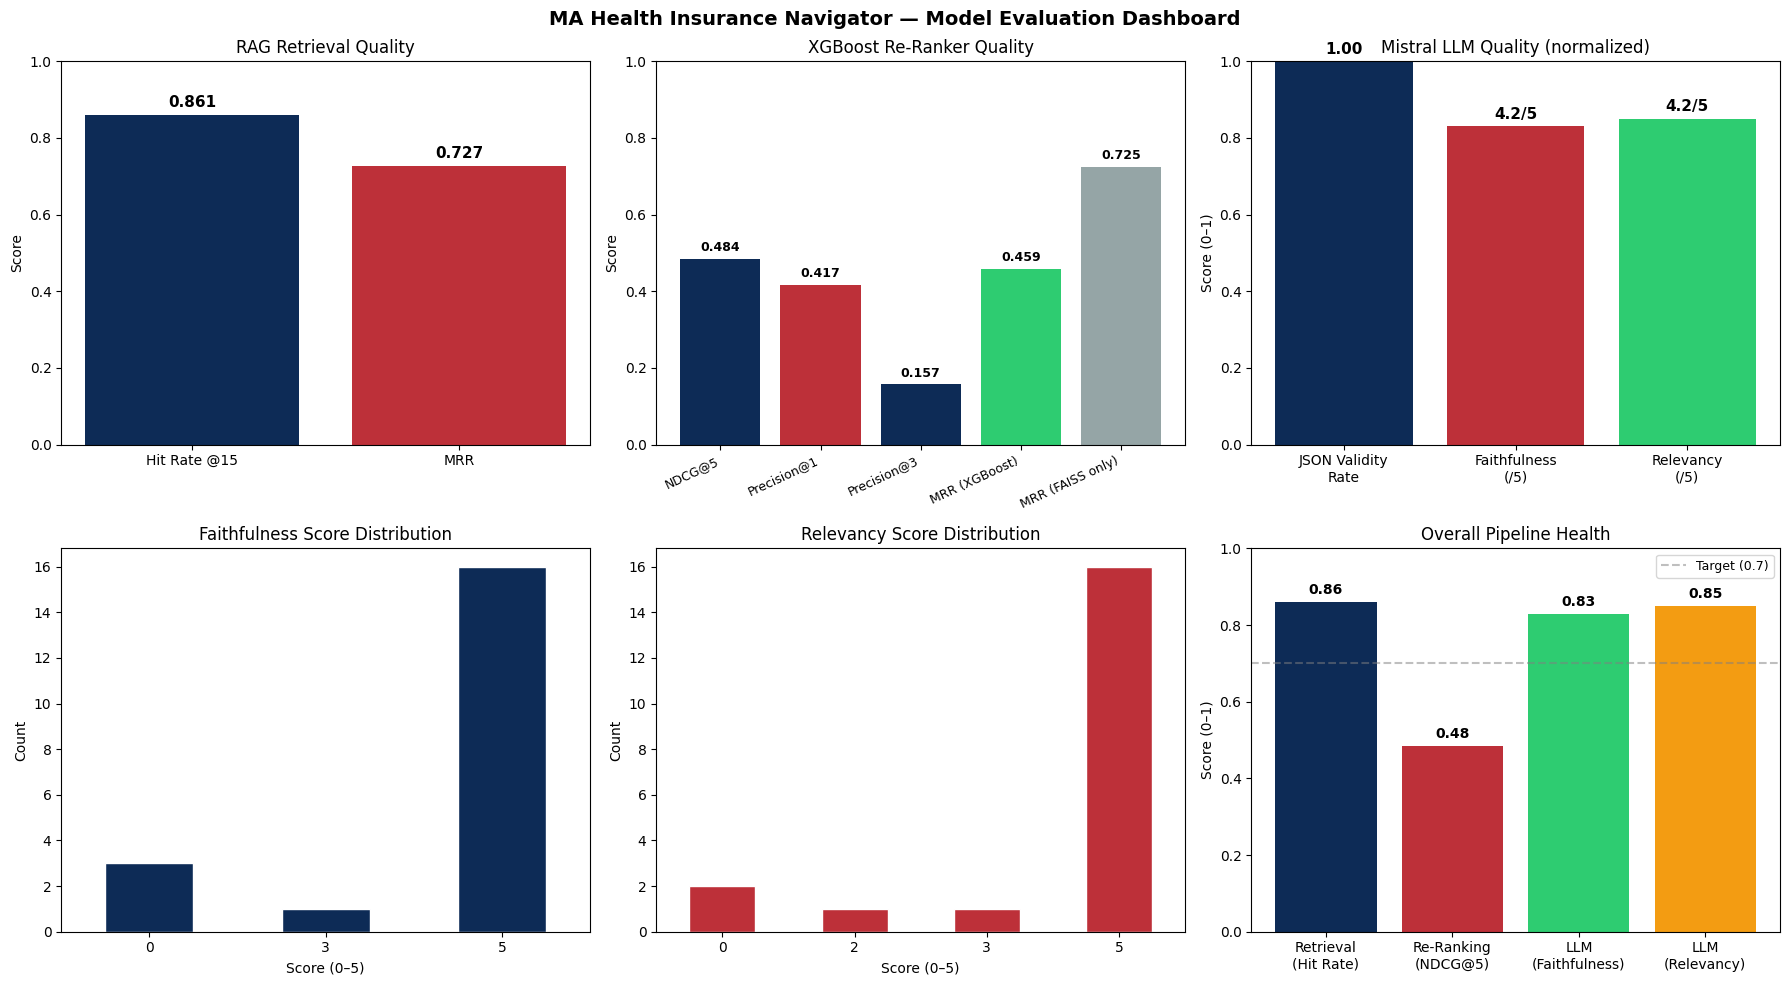


FULL EVALUATION SUMMARY REPORT
RAG Retrieval (FAISS + sentence-transformers)
   Hit Rate @15            : 0.8611
   MRR                     : 0.7265
   Avg FAISS Score         : 0.6
   Total Questions         : 36
XGBoost Re-Ranker
   NDCG@5                  : 0.4843
   Precision@1             : 0.4167
   Precision@3             : 0.1574
   MRR (XGBoost)           : 0.4593
   MRR (FAISS only)        : 0.7245
   MRR Improvement         : -0.2653
Mistral LLM (mistral-small-latest)
   JSON Validity Rate      : 1.0
   Avg Faithfulness /5     : 4.15
   Avg Relevancy /5        : 4.25
   Sample Size             : 20
Overall Pipeline Score   : 0.7564 / 1.0
  Model is performing well — ready for production.


In [ ]:
 #─── CELL 6: Visualization Dashboard ─────────────────────────────────────────
# Plots all evaluation results in one clean dashboard

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("MA Health Insurance Navigator — Model Evaluation Dashboard", fontsize=14, fontweight="bold")

# ── Plot 1: RAG Hit Rate & MRR ────────────────────────────────────────────────
ax = axes[0, 0]
metrics = ["Hit Rate @15", "MRR"]
values  = [rag_results["Hit Rate @15"], rag_results["MRR"]]
bars    = ax.bar(metrics, values, color=["#0D2B56", "#BD3039"])
ax.set_ylim(0, 1)
ax.set_title("RAG Retrieval Quality")
ax.set_ylabel("Score")
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f"{val:.3f}", ha="center", fontsize=11, fontweight="bold")

# ── Plot 2: Re-Ranker Metrics ─────────────────────────────────────────────────
ax = axes[0, 1]
rr_metrics = ["NDCG@5", "Precision@1", "Precision@3", "MRR (XGBoost)", "MRR (FAISS only)"]
rr_values  = [reranker_results[k] for k in rr_metrics]
bars = ax.bar(rr_metrics, rr_values, color=["#0D2B56","#BD3039","#0D2B56","#2ecc71","#95a5a6"])
ax.set_ylim(0, 1)
ax.set_title("XGBoost Re-Ranker Quality")
ax.set_ylabel("Score")
ax.set_xticklabels(rr_metrics, rotation=25, ha="right", fontsize=9)
for bar, val in zip(bars, rr_values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f"{val:.3f}", ha="center", fontsize=9, fontweight="bold")

# ── Plot 3: LLM Quality ───────────────────────────────────────────────────────
ax = axes[0, 2]
llm_metrics = ["JSON Validity\nRate", "Faithfulness\n(/5)", "Relevancy\n(/5)"]
llm_values  = [
    llm_summary["JSON Validity Rate"],
    llm_summary["Avg Faithfulness /5"] / 5,
    llm_summary["Avg Relevancy /5"]    / 5,
]
bars = ax.bar(llm_metrics, llm_values, color=["#0D2B56", "#BD3039", "#2ecc71"])
ax.set_ylim(0, 1)
ax.set_title("Mistral LLM Quality (normalized)")
ax.set_ylabel("Score (0–1)")
labels = [
    f"{llm_summary['JSON Validity Rate']:.2f}",
    f"{llm_summary['Avg Faithfulness /5']:.1f}/5",
    f"{llm_summary['Avg Relevancy /5']:.1f}/5",
]
for bar, label in zip(bars, labels):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            label, ha="center", fontsize=11, fontweight="bold")

# ── Plot 4: Faithfulness Distribution ────────────────────────────────────────
ax = axes[1, 0]
llm_df["faithfulness"].value_counts().sort_index().plot(
    kind="bar", ax=ax, color="#0D2B56", edgecolor="white"
)
ax.set_title("Faithfulness Score Distribution")
ax.set_xlabel("Score (0–5)")
ax.set_ylabel("Count")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

# ── Plot 5: Relevancy Distribution ───────────────────────────────────────────
ax = axes[1, 1]
llm_df["relevancy"].value_counts().sort_index().plot(
    kind="bar", ax=ax, color="#BD3039", edgecolor="white"
)
ax.set_title("Relevancy Score Distribution")
ax.set_xlabel("Score (0–5)")
ax.set_ylabel("Count")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

# ── Plot 6: Overall Pipeline Score ───────────────────────────────────────────
ax = axes[1, 2]
overall = {
    "Retrieval\n(Hit Rate)":  rag_results["Hit Rate @15"],
    "Re-Ranking\n(NDCG@5)":   reranker_results["NDCG@5"],
    "LLM\n(Faithfulness)":    llm_summary["Avg Faithfulness /5"] / 5,
    "LLM\n(Relevancy)":       llm_summary["Avg Relevancy /5"]    / 5,
}
bars = ax.bar(overall.keys(), overall.values(),
              color=["#0D2B56","#BD3039","#2ecc71","#f39c12"])
ax.set_ylim(0, 1)
ax.set_title("Overall Pipeline Health")
ax.set_ylabel("Score (0–1)")
ax.axhline(y=0.7, color="gray", linestyle="--", alpha=0.5, label="Target (0.7)")
ax.legend(fontsize=9)
for bar, val in zip(bars, overall.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f"{val:.2f}", ha="center", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.savefig(f"{EVAL_DIR}/evaluation_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()
#print(f"Dashboard saved → {EVAL_DIR}/evaluation_dashboard.png")


# ─── CELL 7: Final Summary Report ────────────────────────────────────────────
print("\n" + "="*52)
print("FULL EVALUATION SUMMARY REPORT")
print("="*52)

print("RAG Retrieval (FAISS + sentence-transformers)")
for k, v in rag_results.items():
    print(f"   {k:<24}: {v}")

print("XGBoost Re-Ranker")
for k, v in reranker_results.items():
    print(f"   {k:<24}: {v}")

print("Mistral LLM (mistral-small-latest)")
for k, v in llm_summary.items():
    print(f"   {k:<24}: {v}")

# Overall pipeline score (simple average of key metrics)
pipeline_score = round(np.mean([
    rag_results["Hit Rate @15"],
    reranker_results["NDCG@5"],
    llm_summary["Avg Faithfulness /5"] / 5,
    llm_summary["Avg Relevancy /5"]    / 5,
]), 4)

print(f"Overall Pipeline Score   : {pipeline_score} / 1.0")
if pipeline_score >= 0.75:
    print("  Model is performing well — ready for production.")
elif pipeline_score >= 0.55:
    print("  Model is decent — some areas need improvement.")
else:
    print("  Model needs significant work before deployment.")